In [1]:
import sys
from pathlib import Path

import os

# Set the working directory to the root of the project
os.chdir(Path('..').resolve())  # Adjust this path as necessary

# Now append the src directory to the path
import sys
sys.path.append(str(Path('src').resolve()))


# Now import the necessary modules
from pipeline.config import Config
from pipeline.data_loader import StockDataset, download_stock_data, get_sp500_tickers
from pipeline.trainer import Trainer
from pipeline.model import Generator, Discriminator
from pipeline.plotting import plot_training_history
from pipeline.utils import create_data_loaders

# Initialize configuration and check the data directory
config = Config()
print(f"Data directory: {config.data_dir}")

import logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

from pipeline.config import Config

# Fetch S&P 500 tickers and download stock data
tickers = get_sp500_tickers(config)
stock_data = download_stock_data(tickers, config)
# stock_data

INFO:pipeline.data_loader:Loaded data for 495 stocks


Data directory: data
data/stock_data.pkl


In [2]:
# # sys.path.append('gan_finance')
# import os
# os.getcwd()

'/Users/lucijagregov/Documents/gan_finance'

In [3]:
# import logging
# logging.basicConfig(level=logging.INFO)
# logger = logging.getLogger(__name__)


In [4]:
# str(Path('..').resolve() / 'src')

'/Users/lucijagregov/Documents/src'

In [4]:
# from pipeline.config import Config

# config = Config()
# print(f"Data directory: {config.data_dir}")  # This should point to the root project's data directory


Data directory: data


In [2]:
# from pipeline.config import Config

# config = Config()
# print(f"Data directory: {config.data_dir}")  # This should point to the root project's data directory

# config = Config()
# logger.info("Configuration initialized.")

# # Fetch S&P 500 tickers and download stock data
# tickers = get_sp500_tickers(config)
# stock_data = download_stock_data(tickers, config)
# # stock_data

In [49]:
# import pandas as pd

# # Check for missing business dates
# for ticker, df in stock_data.items():
#     # Resample to business days to get the full range of dates
#     full_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq='B')
#     missing_dates = full_range.difference(df.index)  # Find dates in full_range not in df.index
    
#     if not missing_dates.empty:
#         print(f"Missing business dates for {ticker}:")
#         print(missing_dates)
#         print(len(missing_dates))
#     else:
#         print(f"No missing dates for {ticker}")


In [62]:
# Take the first 2 stocks
selected_tickers = tickers[:5]
data_samples = {}

# Extract the first 3 rows for each of the selected stocks
for ticker in selected_tickers:
    data_samples[ticker] = stock_data[ticker].head(3)

# Display the extracted data
data_samples


{'MMM':                   Open        High         Low       Close   Volume
 Date                                                               
 2020-01-02  148.561874  150.510040  148.110367  150.501678  4307633
 2020-01-03  148.010040  149.381271  146.847824  149.205688  2950412
 2020-01-06  148.118729  149.423080  147.449829  149.347824  2389608,
 'AOS':                  Open       High        Low      Close   Volume
 Date                                                           
 2020-01-02  47.910000  47.980000  47.209999  47.770000  1093200
 2020-01-03  47.160000  47.500000  46.750000  47.349998   883200
 2020-01-06  47.130001  47.669998  46.759998  47.650002  1088400,
 'ABT':                  Open       High        Low      Close   Volume
 Date                                                           
 2020-01-02  86.059998  86.959999  85.800003  86.949997  4969000
 2020-01-03  85.750000  86.669998  85.589996  85.889999  4747000
 2020-01-06  85.620003  86.360001  85.209999  8

In [87]:
len(stock_data)

495

In [88]:
import pandas as pd
import numpy as np

# Example stock data
stock_data_example = {
    'MMM': pd.DataFrame({
        'Open': [148.56, 148.01, 148.11],
        'High': [150.51, 149.38, np.nan],  # Introduce NaN
        'Low': [148.11, 146.84, 147.44],
        'Close': [150.50, 149.20, 149.35],
        'Volume': [4307633, 2950412, 2389608]
    }, index=pd.to_datetime(['2020-01-02', '2020-01-03', '2020-01-06'])),
    
    'AOS': pd.DataFrame({
        'Open': [47.91, 47.16, 47.13],
        'High': [47.98, 47.50, 46.67],
        'Low': [47.21, 46.75, 46.76],
        'Close': [47.77, 47.35, 47.65],
        'Volume': [1093200, 883200, 1088400]
    }, index=pd.to_datetime(['2020-01-02', '2020-01-03', '2020-01-07'])),
}

# Determine the overall date range
# min_date = min(df.index.min() for df in stock_data_example.values())
# max_date = max(df.index.max() for df in stock_data_example.values())

min_date = min(df.index.min() for df in stock_data_example.values())
max_date = max(df.index.max() for df in stock_data_example.values())

# Generate the full date range dynamically
all_dates = pd.date_range(start=min_date, end=max_date, freq='B')  # Business days

aligned_data_dict = {}
mask_dict = {}

for stock, df in stock_data_example.items():
    # Align data to the full date range
    df_aligned = df.reindex(all_dates)

    # Create a mask for original non-missing rows
    mask = df_aligned.notna().astype(int)

    # Normalize using Robust normalization
    normalized_data = robust_normalize(df_aligned.values)

    # Create a new DataFrame with normalized values while keeping NaNs
    normalized_df = pd.DataFrame(normalized_data, index=all_dates, columns=df.columns)

    # Apply the mask to maintain NaNs
    normalized_df[mask == 0] = np.nan  # Set normalized values back to NaN where the mask is 0

    aligned_data_dict[stock] = normalized_df
    mask_dict[stock] = mask

# Display the normalized DataFrames
for stock, normalized_df in aligned_data_dict.items():
    print(f"Normalized data for {stock}:")
    print(normalized_df)
    print()

print("Data prepared with aligned dates, normalized features, and masks for missing values.")


Normalized data for MMM:
                Open  High       Low     Close    Volume
2020-01-02  1.636364   1.0  1.055118  1.769231  1.415228
2020-01-03 -0.363636  -1.0 -0.944882 -0.230769  0.000000
2020-01-06  0.000000   NaN  0.000000  0.000000 -0.584772
2020-01-07       NaN   NaN       NaN       NaN       NaN

Normalized data for AOS:
                Open      High       Low     Close    Volume
2020-01-02  1.923077  0.732824  1.956522  0.571429  0.045714
2020-01-03  0.000000  0.000000 -0.043478 -1.428571 -1.954286
2020-01-06       NaN       NaN       NaN       NaN       NaN
2020-01-07 -0.076923 -1.267176  0.000000  0.000000  0.000000

Data prepared with aligned dates, normalized features, and masks for missing values.


In [89]:
dict(list(stock_data.items())[:2])['MMM']

,Open,High,Low,Close,Volume
Date,,,,,
2020-01-02,148.561874,150.510040,148.110367,150.501678,4307633
2020-01-03,148.010040,149.381271,146.847824,149.205688,2950412
2020-01-06,148.118729,149.423080,147.449829,149.347824,2389608
2020-01-07,149.063538,149.255859,147.842804,148.745819,2598908
2020-01-08,148.829437,151.755859,148.536789,151.028427,3298927
...,...,...,...,...,...
2022-12-23,100.994980,101.170570,98.494980,100.451508,3120723
2022-12-27,100.451508,101.028427,99.632111,100.518394,2166195
2022-12-28,100.627090,101.170570,98.871239,98.904678,2345356


In [90]:
import pandas as pd
import numpy as np

def robust_normalize(data: np.ndarray) -> np.ndarray:
    """
    Normalize the input data using the median and IQR method.

    Args:
        data (np.ndarray): The data to normalize, expected to be 2D.

    Returns:
        np.ndarray: Normalized data.
    """
    median = np.nanmedian(data, axis=0)  # Ignore NaNs
    q75, q25 = np.nanpercentile(data, [75, 25], axis=0)
    iqr = q75 - q25
    normalized_data = (data - median) / (iqr + 1e-8)  # Avoid division by zero
    return normalized_data


# Determine the overall date range
min_date = min(df.index.min() for df in stock_data.values())
max_date = max(df.index.max() for df in stock_data.values())

# Generate the full date range dynamically
all_dates = pd.date_range(start=min_date, end=max_date, freq='B')  # Business days

aligned_data_dict = {}
mask_dict = {}

d = dict(list(stock_data.items()))

for stock, df in d.items():
    # Align data to the full date range
    df_aligned = df.reindex(all_dates)

    # Create a mask for original non-missing rows
    mask = df_aligned.notna().astype(int)

    # Normalize using Robust normalization
    normalized_data = robust_normalize(df_aligned.values)

    # Create a new DataFrame with normalized values while keeping NaNs
    normalized_df = pd.DataFrame(normalized_data, index=all_dates, columns=df.columns)

    # Apply the mask to maintain NaNs
    normalized_df[mask == 0] = np.nan  # Set normalized values back to NaN where the mask is 0

    aligned_data_dict[stock] = normalized_df
    mask_dict[stock] = mask

In [91]:

import torch
from torch.utils.data import DataLoader, Dataset, TensorDataset

class StockDataset(Dataset):
    def __init__(self, aligned_data_dict, mask_dict):
        self.data = []
        self.masks = []
        
        for stock in aligned_data_dict.keys():
            # Flatten the normalized data and masks, ignoring NaNs for the dataset
            stock_data = aligned_data_dict[stock].to_numpy().astype(np.float32)
            stock_mask = mask_dict[stock].to_numpy().astype(np.float32)
            
            # Remove NaN rows for training, but keep track of where they were
            valid_data = stock_data[~np.isnan(stock_data).any(axis=1)]
            valid_masks = stock_mask[~np.isnan(stock_mask).any(axis=1)]
            
            self.data.append(valid_data)
            self.masks.append(valid_masks)

        # Concatenate all data into a single tensor
        self.data = np.concatenate(self.data)
        self.masks = np.concatenate(self.masks)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return torch.tensor(self.data[idx]), torch.tensor(self.masks[idx])

# Create dataset and DataLoader
dataset = StockDataset(aligned_data_dict, mask_dict)
dataloader = DataLoader(dataset, batch_size=2, shuffle=True)

In [48]:
782*2

1564

In [44]:
dataset[1]

(tensor([ 0.4131,  0.4194,  0.4207,  0.4668, -0.0842]),
 tensor([1., 1., 1., 1., 1.]))

In [46]:
dataset[2]

(tensor([ 0.4171,  0.4210,  0.4424,  0.4720, -0.4185]),
 tensor([1., 1., 1., 1., 1.]))

In [47]:
len(dataloader.dataset)

1512

In [81]:
import torch
import torch.nn as nn

# class TransformerGenerator(nn.Module):
#     def __init__(self, noise_dim, feature_size, n_layers=2, hidden_size=512):
#         super(TransformerGenerator, self).__init__()

#         # Compute number of heads to be a divisor of hidden_size
#         n_heads = min(hidden_size // 64, 8)  # Start with a default max of 8 heads
#         while hidden_size % n_heads != 0 and n_heads > 1:
#             n_heads -= 1  # Decrease heads until it divides evenly
        
#         self.d_k = hidden_size // n_heads  # Key dimension

#         # Check if n_heads is valid
#         if n_heads < 1:
#             raise ValueError("Number of heads (n_heads) must be at least 1.")

#         self.embedding = nn.Linear(noise_dim, hidden_size)
        
#         self.transformer_blocks = nn.ModuleList([
#             nn.TransformerEncoderLayer(d_model=hidden_size, nhead=n_heads)
#             for _ in range(n_layers)
#         ])
        
#         self.fc_out = nn.Linear(hidden_size, feature_size)

#     def forward(self, x):
#         # Embed the noise
#         x = self.embedding(x).unsqueeze(0)  # Add sequence dimension
#         for transformer in self.transformer_blocks:
#             x = transformer(x)
#         return self.fc_out(x.squeeze(0))  # Remove sequence dimension

# class Discriminator(nn.Module):
#     def __init__(self, feature_size):
#         super(Discriminator, self).__init__()
#         self.model = nn.Sequential(
#             nn.Linear(feature_size, 256),
#             nn.LeakyReLU(0.2),
#             nn.Linear(256, 128),
#             nn.LeakyReLU(0.2),
#             nn.Linear(128, 1),
#             nn.Sigmoid()  # Output probability should be in the range [0, 1]
#         )
        
#     def forward(self, x):
#         return self.model(x)

class TransformerGenerator(nn.Module):
    def __init__(self, noise_dim, feature_size, n_layers, hidden_size):
        super(TransformerGenerator, self).__init__()
        self.noise_dim = noise_dim
        
        n_heads = min(hidden_size // 32, 4)
        while hidden_size % n_heads != 0 and n_heads > 1:
            n_heads -= 1
        
        self.embedding = nn.Linear(noise_dim, hidden_size)
        self.smooth = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.LayerNorm(hidden_size),
            nn.Tanh(),
        )
        
        # Single transformer layer
        self.transformer = nn.TransformerEncoderLayer(
            d_model=hidden_size, 
            nhead=n_heads,
            dim_feedforward=hidden_size * 2,
            dropout=0.1,
            activation='gelu',
            batch_first=True,
            norm_first=True
        )
        
        self.fc_out = nn.Linear(hidden_size, feature_size)

    def forward(self, x):
        x = self.embedding(x)
        x = self.smooth(x)
        x = x.unsqueeze(1)
        x = self.transformer(x)
        return self.fc_out(x.squeeze(1))


# Example parameters
# noise_dim = 5  # Number of noise dimensions
# feature_size = len(aligned_data_dict['MMM'].columns)  # Number of features (Open, High, Low, Close, Volume)
# hidden_size = 512  # Total hidden size

# # Instantiate the models
# generator = TransformerGenerator(noise_dim, feature_size, hidden_size=hidden_size)
# discriminator = Discriminator(feature_size)

# print("Generator:")
# print(generator)
# print("\nDiscriminator:")
# print(discriminator)


In [95]:
list(aligned_data_dict.keys())[0]

'MMM'

Feature size: 5
Dataset size: 1512
Number of batches: 47


Epoch 1/100: 100%|██████████| 47/47 [00:00<00:00, 104.81it/s, D_loss=1.3465, G_loss=0.7029]



New best loss: 0.7023 at epoch 1


Epoch 7/100: 100%|██████████| 47/47 [00:00<00:00, 106.31it/s, D_loss=1.2897, G_loss=0.6907]



New best loss: 0.6956 at epoch 7


...


New best loss: 0.6849 at epoch 9


Epoch 12/100: 100%|██████████| 47/47 [00:00<00:00, 96.46it/s, D_loss=1.3816, G_loss=0.6812] 



New best loss: 0.6837 at epoch 12


Epoch 22/100: 100%|██████████| 47/47 [00:00<00:00, 80.73it/s, D_loss=1.3127, G_loss=0.6915]



Early stopping triggered after 22 epochs
Training completed. Best loss: 0.6837


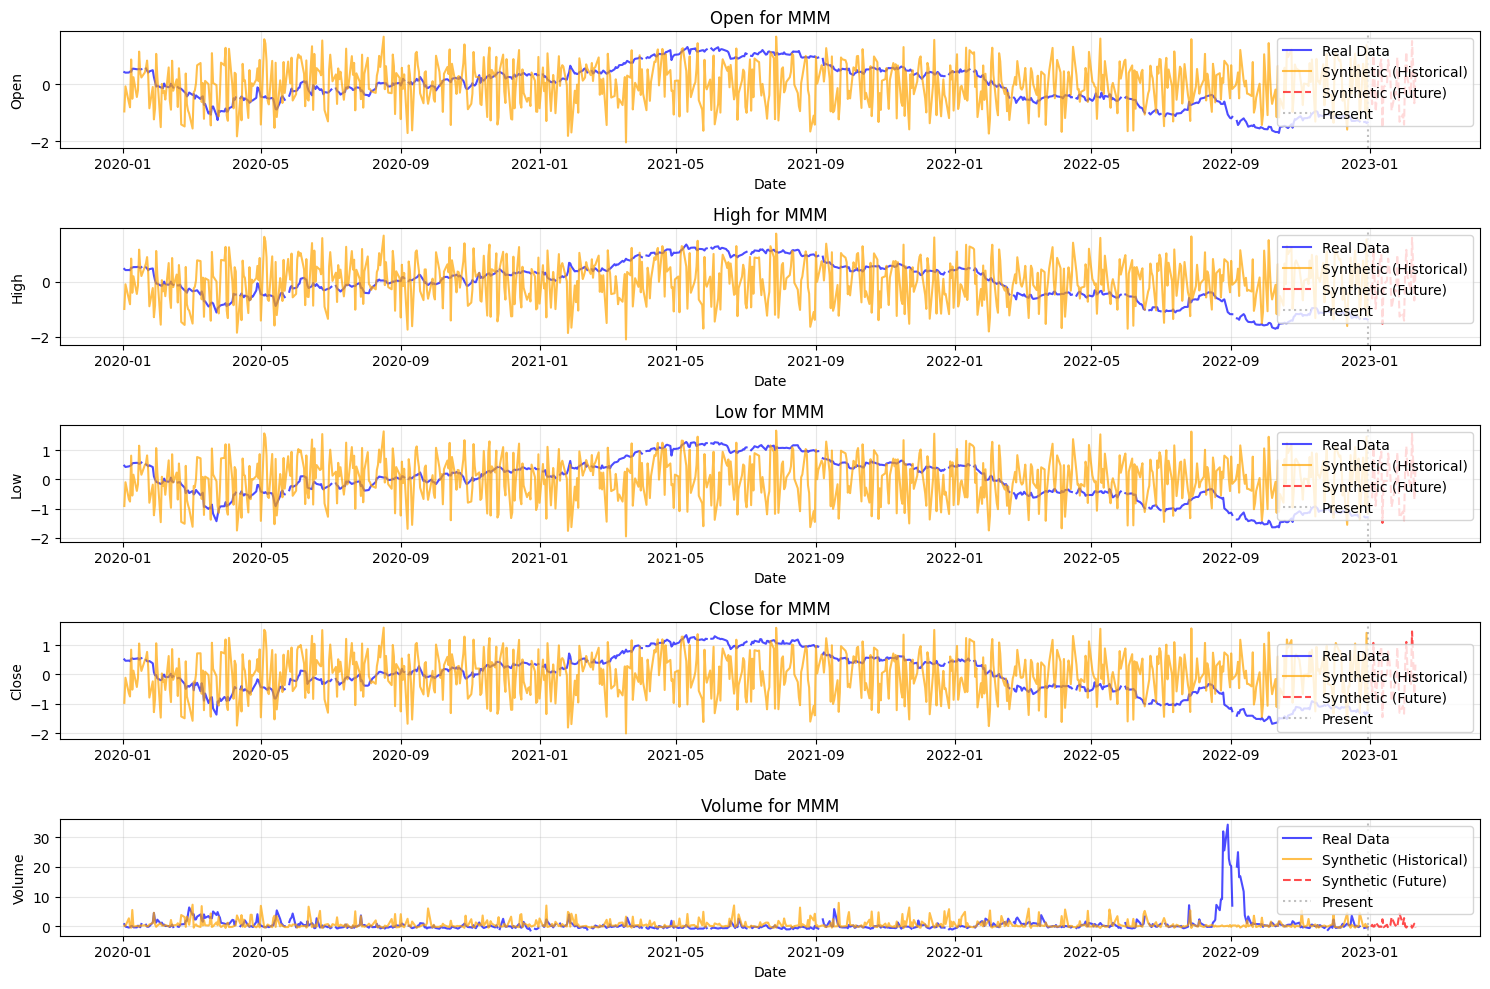

In [85]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
from tqdm import tqdm
from typing import Dict, Tuple

# All constants defined at the top
NOISE_DIM = 32      # Latent space dimension
HIDDEN_SIZE = 64    # Hidden layer size
N_LAYERS = 2        # Number of transformer layers
BATCH_SIZE = 32     # Training batch size
N_EPOCHS = 100      # Number of training epochs
LEARNING_RATE = 0.0002  # Learning rate for optimizers
PATIENCE = 10       # Early stopping patience
MIN_DELTA = 0.001   # Minimum improvement for early stopping

# Set CPU optimization
torch.set_num_threads(4)

class StockDataset(Dataset):
    def __init__(self, aligned_data_dict: Dict[str, pd.DataFrame], 
                 mask_dict: Dict[str, np.ndarray]):
        self.data = []
        self.masks = []
        
        for stock in aligned_data_dict.keys():
            stock_data = aligned_data_dict[stock].to_numpy().astype(np.float32)
            stock_mask = mask_dict[stock].to_numpy().astype(np.float32)
            
            valid_data = stock_data[~np.isnan(stock_data).any(axis=1)]
            valid_masks = stock_mask[~np.isnan(stock_mask).any(axis=1)]
            
            self.data.append(valid_data)
            self.masks.append(valid_masks)
        
        self.data = np.concatenate(self.data)
        self.masks = np.concatenate(self.masks)
    
    def __len__(self) -> int:
        return len(self.data)
    
    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor]:
        return torch.tensor(self.data[idx]), torch.tensor(self.masks[idx])

def create_dataloader(aligned_data_dict, mask_dict, batch_size):
    dataset = StockDataset(aligned_data_dict, mask_dict)
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
        pin_memory=False
    )

def train_gan_simple(dataloader, generator, discriminator, device='cpu'):
    """CPU-optimized training with early stopping"""
    optimizer_G = optim.Adam(generator.parameters(), lr=LEARNING_RATE, betas=(0.5, 0.999))
    optimizer_D = optim.Adam(discriminator.parameters(), lr=LEARNING_RATE, betas=(0.5, 0.999))
    criterion = nn.BCELoss()
    
    # Early stopping setup
    best_loss = float('inf')
    patience_counter = 0
    best_state = None
    
    # Moving average for loss smoothing
    ema_g_loss = None
    ema_alpha = 0.98
    
    try:
        for epoch in range(N_EPOCHS):
            pbar = tqdm(dataloader, desc=f'Epoch {epoch+1}/{N_EPOCHS}')
            epoch_losses = []
            
            for real_data, masks in pbar:
                current_batch_size = real_data.size(0)
                
                # Create labels for current batch size
                real_labels = torch.ones(current_batch_size, 1, device=device)
                fake_labels = torch.zeros(current_batch_size, 1, device=device)
                
                # Move data to device
                real_data = real_data.to(device)
                masks = masks.to(device)
                
                # Train Discriminator
                optimizer_D.zero_grad(set_to_none=True)
                real_outputs = discriminator(real_data)
                d_loss_real = criterion(real_outputs * masks, real_labels * masks)
                
                # Generate fake data
                noise = torch.randn(current_batch_size, generator.noise_dim, device=device)
                fake_data = generator(noise)
                fake_outputs = discriminator(fake_data.detach())
                d_loss_fake = criterion(fake_outputs * masks, fake_labels * masks)
                
                d_loss = d_loss_real + d_loss_fake
                d_loss.backward()
                optimizer_D.step()
                
                # Train Generator
                optimizer_G.zero_grad(set_to_none=True)
                fake_outputs = discriminator(fake_data)
                g_loss = criterion(fake_outputs * masks, real_labels * masks)
                g_loss.backward()
                optimizer_G.step()
                
                # Update EMA loss
                g_loss_item = g_loss.item()
                ema_g_loss = g_loss_item if ema_g_loss is None else ema_g_loss * ema_alpha + g_loss_item * (1 - ema_alpha)
                epoch_losses.append(ema_g_loss)
                
                pbar.set_postfix({
                    'D_loss': f'{d_loss.item():.4f}',
                    'G_loss': f'{ema_g_loss:.4f}'
                })
            
            # Early stopping check
            avg_loss = np.mean(epoch_losses)
            if avg_loss < best_loss - MIN_DELTA:
                best_loss = avg_loss
                patience_counter = 0
                best_state = {
                    'generator': generator.state_dict(),
                    'discriminator': discriminator.state_dict(),
                    'epoch': epoch,
                    'g_loss': avg_loss
                }
                print(f"\nNew best loss: {avg_loss:.4f} at epoch {epoch + 1}")
            else:
                patience_counter += 1
                if patience_counter >= PATIENCE:
                    print(f"\nEarly stopping triggered after {epoch + 1} epochs")
                    generator.load_state_dict(best_state['generator'])
                    discriminator.load_state_dict(best_state['discriminator'])
                    break
            
            if (epoch + 1) % 10 == 0:
                torch.save(best_state, f'checkpoint_epoch_{epoch+1}.pth')
    
    except KeyboardInterrupt:
        print("\nTraining interrupted by user")
        if best_state:
            print("Loading best model...")
            generator.load_state_dict(best_state['generator'])
            discriminator.load_state_dict(best_state['discriminator'])
    
    print(f"Training completed. Best loss: {best_loss:.4f}")
    return best_state

# Usage
feature_size = len(aligned_data_dict['MMM'].columns)
print(f"Feature size: {feature_size}")

# Initialize models
generator = TransformerGenerator(
    noise_dim=NOISE_DIM,
    feature_size=feature_size,
    n_layers=N_LAYERS,
    hidden_size=HIDDEN_SIZE
)
discriminator = Discriminator(feature_size)

# Create dataloader with drop_last=True to ensure consistent batch sizes
dataloader = DataLoader(
    StockDataset(aligned_data_dict, mask_dict),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=False,
    drop_last=True  # Added this to avoid inconsistent batch sizes
)

print(f"Dataset size: {len(dataloader.dataset)}")
print(f"Number of batches: {len(dataloader)}")

# Train
best_state = train_gan_simple(
    dataloader=dataloader,
    generator=generator,
    discriminator=discriminator
)

# Generate synthetic data
generator.load_state_dict(best_state['generator'])
real_data = aligned_data_dict['MMM']

synthetic_df = generate_synthetic_data(
    generator=generator,
    real_data=real_data,
    future_days=30
)

# Plot results
plot_real_vs_synthetic(
    real_data=real_data,
    synthetic_data=synthetic_df,
    stock_name='MMM',
    future_days=30,
    save_path='synthetic_comparison.png'
)

In [41]:
len(dataloader.dataset)

1512

In [54]:
import torch.optim as optim

# Model parameters
num_epochs = 200
batch_size = 32  # Batch size as defined earlier

# Move models to the appropriate device (CPU or GPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
generator.to(device)
discriminator.to(device)

# Optimizers
optimizer_G = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))

# Loss function
criterion = nn.BCELoss()  # Binary Cross-Entropy Loss

# Training Loop
for epoch in range(num_epochs):
    print(epoch)
    for real_data, masks in dataloader:
        real_data = real_data.to(device)
        masks = masks.to(device)  # Masks are now in the right device
        
        # Create labels
        batch_size = real_data.size(0)
        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)
        # print('real_labels', real_labels)
        # print('fake_labels', fake_labels)
        # Train Discriminator
        optimizer_D.zero_grad()

        # Compute the discriminator's output on real data
        real_outputs = discriminator(real_data)

        # Apply masks to only consider valid entries for loss calculation
        d_loss_real = criterion(real_outputs * masks, real_labels * masks)

        # Generate fake data
        noise = torch.randn(batch_size, noise_dim).to(device)
        fake_data = generator(noise)

        # Compute the discriminator's output on fake data
        fake_outputs = discriminator(fake_data.detach())  # Detach to not backpropagate through generator
        # print('fake_outputs', fake_outputs)
        # Apply masks for the fake data loss calculation
        d_loss_fake = criterion(fake_outputs * masks, fake_labels * masks)

        # Total discriminator loss
        d_loss = d_loss_real + d_loss_fake
        d_loss.backward()
        optimizer_D.step()

        # Train Generator
        optimizer_G.zero_grad()

        # Compute the generator's output
        fake_outputs = discriminator(fake_data)  # No detach here for backpropagation

        # Apply masks to consider only valid entries for generator loss
        g_loss = criterion(fake_outputs * masks, real_labels * masks)  # We want to fool the discriminator

        g_loss.backward()
        optimizer_G.step()

    # Print loss values for tracking
    if (epoch + 1) % 2 == 0:  # Print every 100 epochs
        print(f"Epoch [{epoch + 1}/{num_epochs}], Loss D: {d_loss.item():.4f}, Loss G: {g_loss.item():.4f}")

# Save the models after training
torch.save(generator.state_dict(), 'generator.pth')
torch.save(discriminator.state_dict(), 'discriminator.pth')
print("Models saved after training.")


0
1
Epoch [2/200], Loss D: 1.3554, Loss G: 0.7596
2


KeyboardInterrupt: 

In [79]:
import torch
import torch.nn as nn

# Global parameters based on dataset characteristics
# NOISE_DIM = 100     # Standard GAN practice for complex financial data
# HIDDEN_SIZE = 512   # Power of 2, good for ~370k samples and 5 features
# N_LAYERS = 3        # Good for capturing complex financial patterns
# BATCH_SIZE = 128    # Larger batch size for stable training
# N_EPOCHS = 10      # Standard starting point
# LEARNING_RATE = 0.0002  # Standard GAN learning rate

NOISE_DIM = 32      # Reduced from 100
HIDDEN_SIZE = 64    # Reduced from 512
N_LAYERS = 2        # Reduced from 3
BATCH_SIZE = 32     # Reduced from 128
N_EPOCHS = 100      # Increased for better learning


class TransformerGenerator(nn.Module):
    def __init__(self, noise_dim, feature_size, n_layers, hidden_size):
        super(TransformerGenerator, self).__init__()
        
        self.noise_dim = noise_dim

        # Compute number of heads - for hidden_size 512, this will be 8
        n_heads = min(hidden_size // 64, 8)
        while hidden_size % n_heads != 0 and n_heads > 1:
            n_heads -= 1
        
        self.d_k = hidden_size // n_heads

        if n_heads < 1:
            raise ValueError("Number of heads (n_heads) must be at least 1.")

        self.embedding = nn.Linear(noise_dim, hidden_size)
        
        self.transformer_blocks = nn.ModuleList([
            nn.TransformerEncoderLayer(
                d_model=hidden_size, 
                nhead=n_heads,
                dim_feedforward=hidden_size * 4,  # Standard transformer practice
                dropout=0.1,
                activation='gelu'  # Better than ReLU for transformers
            )
            for _ in range(n_layers)
        ])
        
        self.fc_out = nn.Linear(hidden_size, feature_size)

    def forward(self, x):
        x = self.embedding(x).unsqueeze(0)
        for transformer in self.transformer_blocks:
            x = transformer(x)
        return self.fc_out(x.squeeze(0))

class Discriminator(nn.Module):
    def __init__(self, feature_size):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(feature_size, 512),  # Matched with generator's capacity
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),  # Added dropout for stability
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )
        
    def forward(self, x):
        return self.model(x)

# Initialize models
feature_size = len(aligned_data_dict['MMM'].columns)

generator = TransformerGenerator(
    noise_dim=NOISE_DIM,
    feature_size=feature_size,
    n_layers=N_LAYERS,
    hidden_size=HIDDEN_SIZE
)
discriminator = Discriminator(feature_size)

def train_gan_simple(dataloader, generator, discriminator, device='cpu'):
    optimizer_G = optim.Adam(generator.parameters(), lr=LEARNING_RATE, betas=(0.5, 0.999))
    optimizer_D = optim.Adam(discriminator.parameters(), lr=LEARNING_RATE, betas=(0.5, 0.999))
    criterion = nn.BCELoss()

    batch_size = dataloader.batch_size
    real_labels = torch.ones(batch_size, 1).to(device)
    fake_labels = torch.zeros(batch_size, 1).to(device)

    for epoch in range(N_EPOCHS):
        pbar = tqdm(dataloader, desc=f'Epoch {epoch+1}/{N_EPOCHS}')
        
        for real_data, masks in pbar:
            real_data = real_data.to(device)
            masks = masks.to(device)
            current_batch_size = real_data.size(0)

            if current_batch_size != batch_size:
                real_labels = torch.ones(current_batch_size, 1).to(device)
                fake_labels = torch.zeros(current_batch_size, 1).to(device)

            # Train Discriminator
            optimizer_D.zero_grad()
            real_outputs = discriminator(real_data)
            d_loss_real = criterion(real_outputs * masks, real_labels * masks)
            
            noise = torch.randn(current_batch_size, generator.noise_dim, device=device)
            fake_data = generator(noise)
            fake_outputs = discriminator(fake_data.detach())
            d_loss_fake = criterion(fake_outputs * masks, fake_labels * masks)
            
            d_loss = d_loss_real + d_loss_fake
            d_loss.backward()
            optimizer_D.step()

            # Train Generator
            optimizer_G.zero_grad()
            fake_outputs = discriminator(fake_data)
            g_loss = criterion(fake_outputs * masks, real_labels * masks)
            g_loss.backward()
            optimizer_G.step()

            pbar.set_postfix({
                'D_loss': f'{d_loss.item():.4f}',
                'G_loss': f'{g_loss.item():.4f}'
            })

    torch.save(generator.state_dict(), 'generator.pth')
    torch.save(discriminator.state_dict(), 'discriminator.pth')
    print("Training completed and models saved.")

# Move models to device and train
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
generator.to(device)
discriminator.to(device)

# Create dataloader with optimal batch size
# dataloader = create_dataloader(
#     aligned_data_dict,
#     mask_dict,
#     batch_size=BATCH_SIZE,
#     max_samples=None  # Use all samples
# )

train_gan_simple(
    dataloader=dataloader,
    generator=generator,
    discriminator=discriminator,
    device=device
)

Epoch 5/100:  37%|███▋      | 278/756 [00:08<00:14, 33.82it/s, D_loss=1.4039, G_loss=0.6556]


KeyboardInterrupt: 

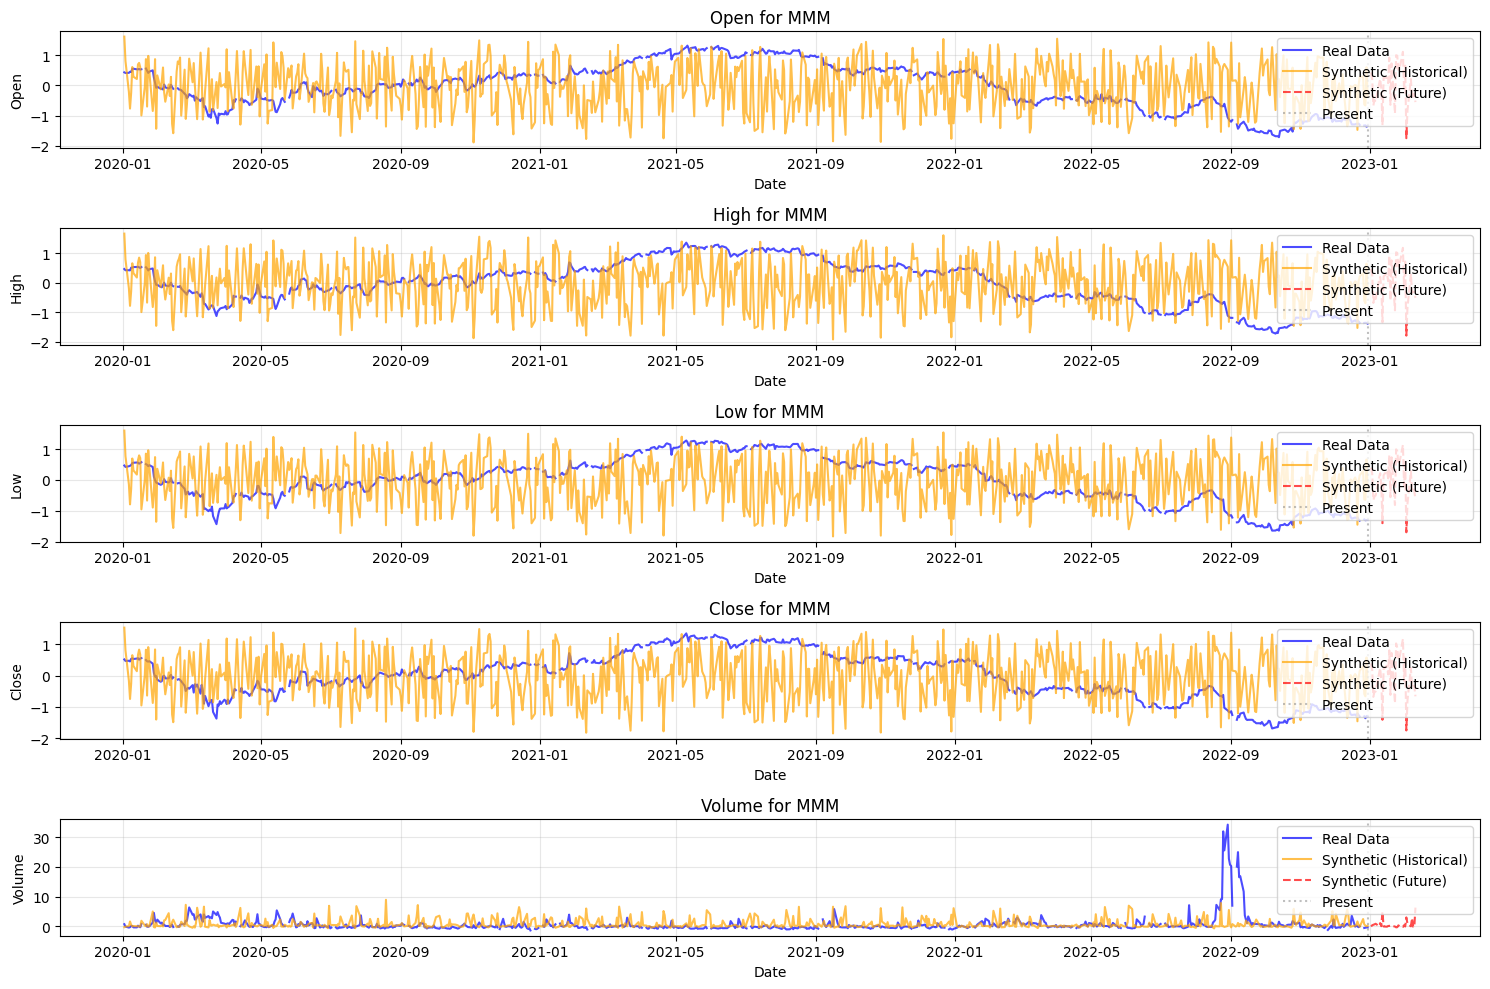

In [98]:
from typing import Dict, Tuple, List, Optional
import matplotlib.pyplot as plt

def generate_synthetic_data(
    generator: nn.Module,
    real_data: pd.DataFrame,
    future_days: int = 0,
    device: str = 'cpu',
    num_samples: Optional[int] = None
) -> pd.DataFrame:
    """
    Generate synthetic stock data using the trained generator.
    
    Args:
        generator (nn.Module): Trained generator model
        real_data (pd.DataFrame): Real stock data DataFrame to match dates with
        future_days (int): Number of days to predict into the future
        device (str): Device to use for generation
        num_samples (Optional[int]): Number of samples to generate
    """
    generator.eval()
    
    # Determine number of samples to generate
    if num_samples is None:
        num_samples = len(real_data) + future_days
    
    # Generate future dates if needed
    if future_days > 0:
        future_dates = pd.date_range(
            start=real_data.index[-1] + pd.Timedelta(days=1),
            periods=future_days,
            freq='B'
        )
        dates = real_data.index.union(future_dates)
    else:
        dates = real_data.index
    
    # Use the generator's noise_dim attribute
    noise = torch.randn(num_samples, generator.noise_dim, device=device)
    with torch.no_grad():
        synthetic_data = generator(noise).cpu().numpy()
    
    # Create DataFrame
    synthetic_df = pd.DataFrame(
        synthetic_data[:len(dates)],
        index=dates,
        columns=real_data.columns
    )
    
    return synthetic_df


def plot_training_history(history: Dict[str, List[float]], save_path: Optional[str] = None):
    """
    Plot training history with all loss components.
    
    Args:
        history (Dict[str, List[float]]): Dictionary containing training history
        save_path (Optional[str]): Path to save the plot. If None, displays instead
    """
    plt.figure(figsize=(15, 10))
    
    for i, (loss_name, values) in enumerate(history.items(), 1):
        plt.subplot(len(history), 1, i)
        plt.plot(values, label=loss_name)
        plt.title(f'{loss_name} over Training')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.grid(True, alpha=0.3)
        plt.legend()
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path)
    plt.show()

def plot_real_vs_synthetic(
    real_data: pd.DataFrame,
    synthetic_data: pd.DataFrame,
    stock_name: str,
    future_days: int = 0,
    save_path: Optional[str] = None
):
    """
    Plot comparison between real and synthetic data with future predictions.
    
    Args:
        real_data (pd.DataFrame): Real stock data
        synthetic_data (pd.DataFrame): Generated synthetic data
        stock_name (str): Name of the stock for plot titles
        future_days (int): Number of future days predicted
        save_path (Optional[str]): Path to save the plot
    """
    features = real_data.columns
    plt.figure(figsize=(15, 10))
    
    for i, feature in enumerate(features, 1):
        plt.subplot(len(features), 1, i)
        
        # Plot historical data
        plt.plot(real_data.index, real_data[feature], 
                label='Real Data', color='blue', alpha=0.7)
        
        # Plot synthetic historical data
        historical_mask = synthetic_data.index <= real_data.index[-1]
        plt.plot(synthetic_data[historical_mask].index,
                synthetic_data[historical_mask][feature],
                label='Synthetic (Historical)', color='orange', alpha=0.7)
        
        # Plot future predictions if they exist
        if future_days > 0:
            future_mask = synthetic_data.index > real_data.index[-1]
            plt.plot(synthetic_data[future_mask].index,
                    synthetic_data[future_mask][feature],
                    label='Synthetic (Future)', color='red', alpha=0.7,
                    linestyle='--')
            
            plt.axvline(x=real_data.index[-1], color='gray', 
                       linestyle=':', alpha=0.5,
                       label='Present')
        
        plt.title(f'{feature} for {stock_name}')
        plt.xlabel('Date')
        plt.ylabel(feature)
        plt.legend()
        plt.grid(True, alpha=0.3)
        
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path)
    plt.show()


# Now use it:
real_data = aligned_data_dict['MMM']
synthetic_df = generate_synthetic_data(
    generator=generator,
    real_data=real_data,
    future_days=30,
    device=device
)

# Plot results
plot_real_vs_synthetic(
    real_data=real_data,
    synthetic_data=synthetic_df,
    stock_name='MMM',
    future_days=30,
    save_path='synthetic_comparison.png'
)

In [100]:
n_samples = len(real_data)
n_samples

782

In [101]:
dates = real_data.index
dates

DatetimeIndex(['2020-01-02', '2020-01-03', '2020-01-06', '2020-01-07',
               '2020-01-08', '2020-01-09', '2020-01-10', '2020-01-13',
               '2020-01-14', '2020-01-15',
               ...
               '2022-12-19', '2022-12-20', '2022-12-21', '2022-12-22',
               '2022-12-23', '2022-12-26', '2022-12-27', '2022-12-28',
               '2022-12-29', '2022-12-30'],
              dtype='datetime64[ns]', length=782, freq='B')

In [68]:
import torch

# Set the generator to evaluation mode
generator.eval()

# Number of samples to generate
num_samples = 180  # Generate data for the next 180 days

# Generate random noise
noise = torch.randn(num_samples, noise_dim).to(device)

# Generate synthetic data
with torch.no_grad():
    synthetic_data = generator(noise).cpu().numpy()

# Convert the synthetic data back to a DataFrame for easier manipulation
synthetic_df = pd.DataFrame(synthetic_data, columns=aligned_data_dict['MMM'].columns)
synthetic_df.index = pd.date_range(start='2023-01-09', periods=num_samples, freq='B')  # Assuming you want to generate from Jan 9, 2023

# Display the first few rows of the synthetic data
print("Generated Synthetic Data:")
print(synthetic_df.head())



# Plotting real vs synthetic data for MMM
plt.figure(figsize=(12, 6))
plt.plot(aligned_data_dict['MMM'].index, aligned_data_dict['MMM']['Close'], label='Real Data (MMM)', color='blue')
plt.plot(synthetic_df.index, synthetic_df['Close'], label='Synthetic Data (MMM)', color='orange')
plt.title('Real vs Synthetic Stock Prices for MMM')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()


RuntimeError: mat1 and mat2 shapes cannot be multiplied (180x20 and 100x512)

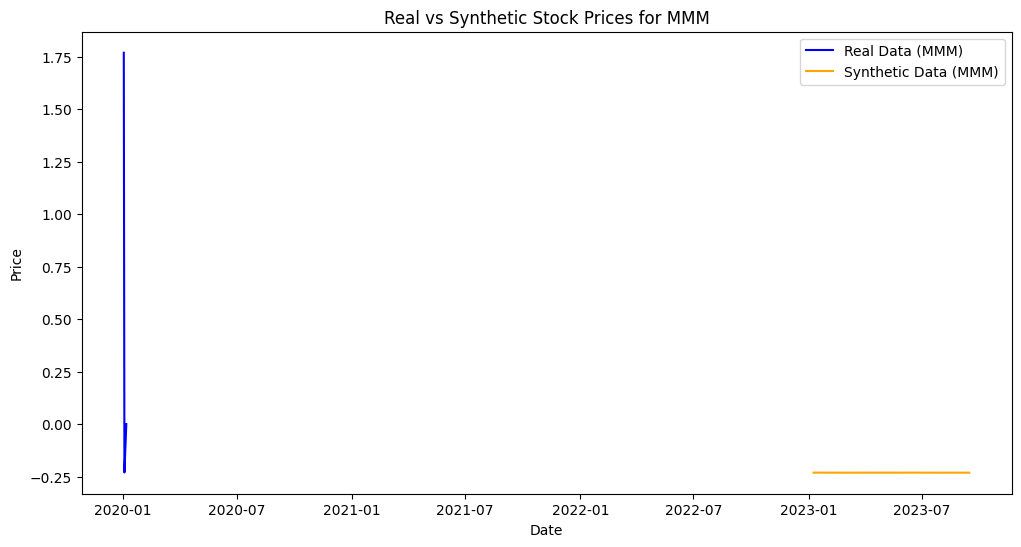

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Function to generate synthetic data for the next 180 days
def generate_synthetic_data(generator, noise_dim, num_samples=180):
    noise = torch.randn(num_samples, noise_dim).to(device)  # Generate noise
    with torch.no_grad():  # No need to track gradients for generation
        generated_data = generator(noise).cpu().numpy()  # Generate synthetic data
    return generated_data

# Generate synthetic data
num_samples = 180
synthetic_data = generate_synthetic_data(generator, noise_dim, num_samples)

# Convert synthetic data to DataFrame
synthetic_df = pd.DataFrame(synthetic_data, columns=aligned_data_dict['MMM'].columns)
synthetic_df.index = pd.date_range(start='2023-01-09', periods=num_samples, freq='B')  # Assuming you want to generate from Jan 9, 2023

# Plotting real vs synthetic data for MMM
plt.figure(figsize=(12, 6))
plt.plot(aligned_data_dict['MMM'].index, aligned_data_dict['MMM']['Close'], label='Real Data (MMM)', color='blue')
plt.plot(synthetic_df.index, synthetic_df['Close'], label='Synthetic Data (MMM)', color='orange')
plt.title('Real vs Synthetic Stock Prices for MMM')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()


In [36]:
synthetic_df

,Open,High,Low,Close,Volume
2023-01-09,-0.405698,-0.965962,-0.905420,-0.231712,-0.019449
2023-01-10,-0.405717,-0.966019,-0.905463,-0.231922,-0.019466
2023-01-11,-0.405721,-0.965917,-0.905416,-0.231683,-0.019412
2023-01-12,-0.405833,-0.966141,-0.905433,-0.231596,-0.019450
2023-01-13,-0.405675,-0.965985,-0.905354,-0.231817,-0.019444
...,...,...,...,...,...
2023-09-11,-0.405817,-0.966117,-0.905454,-0.231835,-0.019432
2023-09-12,-0.405704,-0.965888,-0.905383,-0.231619,-0.019418
2023-09-13,-0.405708,-0.966024,-0.905375,-0.231921,-0.019403
2023-09-14,-0.405603,-0.965762,-0.905312,-0.231733,-0.019384


## Create functions out of the code above

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, TensorDataset
import matplotlib.pyplot as plt

import sys
from pathlib import Path

import os

# Set the working directory to the root of the project
os.chdir(Path('..').resolve())  # Adjust this path as necessary

# Now append the src directory to the path
import sys
sys.path.append(str(Path('src').resolve()))


# Now import the necessary modules
from pipeline.config import Config
from pipeline.data_loader import StockDataset, download_stock_data, get_sp500_tickers
from pipeline.trainer import Trainer
from pipeline.model import Generator, Discriminator
from pipeline.plotting import plot_training_history
from pipeline.utils import create_data_loaders

# Initialize configuration and check the data directory
config = Config()
print(f"Data directory: {config.data_dir}")

import logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

from pipeline.config import Config

# Fetch S&P 500 tickers and download stock data
tickers = get_sp500_tickers(config)
stock_data = download_stock_data(tickers, config)
# stock_data

def robust_normalize(data: np.ndarray) -> np.ndarray:
    """
    Normalize the input data using the median and IQR method.

    Args:
        data (np.ndarray): The data to normalize, expected to be 2D.

    Returns:
        np.ndarray: Normalized data.
    """
    median = np.nanmedian(data, axis=0)  # Ignore NaNs
    q75, q25 = np.nanpercentile(data, [75, 25], axis=0)
    iqr = q75 - q25
    normalized_data = (data - median) / (iqr + 1e-8)  # Avoid division by zero
    return normalized_data


def prepare_data(stock_data: dict) -> tuple:
    """
    Prepare the stock data by normalizing and creating masks for missing values.

    Args:
        stock_data (dict): Dictionary of stock data DataFrames keyed by stock names.

    Returns:
        tuple: Aligned data dictionary and mask dictionary.
    """
    # Determine the overall date range
    min_date = min(df.index.min() for df in stock_data.values())
    max_date = max(df.index.max() for df in stock_data.values())

    # Generate the full date range dynamically
    all_dates = pd.date_range(start=min_date, end=max_date, freq='B')  # Business days

    aligned_data_dict = {}
    mask_dict = {}

    for stock, df in stock_data.items():
        # Align data to the full date range
        df_aligned = df.reindex(all_dates)

        # Create a mask for original non-missing rows
        mask = df_aligned.notna().astype(int)

        # Normalize using Robust normalization
        normalized_data = robust_normalize(df_aligned.values)

        # Create a new DataFrame with normalized values while keeping NaNs
        normalized_df = pd.DataFrame(normalized_data, index=all_dates, columns=df.columns)

        # Apply the mask to maintain NaNs
        normalized_df[mask == 0] = np.nan  # Set normalized values back to NaN where the mask is 0

        aligned_data_dict[stock] = normalized_df
        mask_dict[stock] = mask

    return aligned_data_dict, mask_dict


class StockDataset(Dataset):
    """
    Custom Dataset for stock data.

    Args:
        aligned_data_dict (dict): Dictionary of normalized stock data.
        mask_dict (dict): Dictionary of masks indicating valid data.
    """
    def __init__(self, aligned_data_dict: dict, mask_dict: dict):
        self.data = []
        self.masks = []
        
        for stock in aligned_data_dict.keys():
            # Flatten the normalized data and masks, ignoring NaNs for the dataset
            stock_data = aligned_data_dict[stock].to_numpy().astype(np.float32)
            stock_mask = mask_dict[stock].to_numpy().astype(np.float32)
            
            # Remove NaN rows for training, but keep track of where they were
            valid_data = stock_data[~np.isnan(stock_data).any(axis=1)]
            valid_masks = stock_mask[~np.isnan(stock_mask).any(axis=1)]
            
            self.data.append(valid_data)
            self.masks.append(valid_masks)

        # Concatenate all data into a single tensor
        self.data = np.concatenate(self.data)
        self.masks = np.concatenate(self.masks)

    def __len__(self) -> int:
        return len(self.data)

    def __getitem__(self, idx: int) -> tuple:
        return torch.tensor(self.data[idx]), torch.tensor(self.masks[idx])


# class TransformerGenerator(nn.Module):
#     """
#     Generator model using a Transformer architecture.

#     Args:
#         noise_dim (int): Dimension of the noise vector.
#         feature_size (int): Number of features in the output data.
#         n_layers (int): Number of transformer layers.
#         hidden_size (int): Size of hidden layers.
#     """
#     def __init__(self, noise_dim: int, feature_size: int, n_layers: int = 2, hidden_size: int = 512):
#         super(TransformerGenerator, self).__init__()

#         # Compute number of heads to be a divisor of hidden_size
#         n_heads = min(hidden_size // 64, 8)  # Start with a default max of 8 heads
#         while hidden_size % n_heads != 0 and n_heads > 1:
#             n_heads -= 1  # Decrease heads until it divides evenly
        
#         self.d_k = hidden_size // n_heads  # Key dimension

#         # Check if n_heads is valid
#         if n_heads < 1:
#             raise ValueError("Number of heads (n_heads) must be at least 1.")

#         self.embedding = nn.Linear(noise_dim, hidden_size)
        
#         self.transformer_blocks = nn.ModuleList([
#             nn.TransformerEncoderLayer(d_model=hidden_size, nhead=n_heads)
#             for _ in range(n_layers)
#         ])
        
#         self.fc_out = nn.Linear(hidden_size, feature_size)

#     def forward(self, x: torch.Tensor) -> torch.Tensor:
#         # Embed the noise
#         x = self.embedding(x).unsqueeze(0)  # Add sequence dimension
#         for transformer in self.transformer_blocks:
#             x = transformer(x)
#         return self.fc_out(x.squeeze(0))  # Remove sequence dimension

class TransformerGenerator(nn.Module):
    """
    Generator model using a Transformer architecture.

    Args:
        noise_dim (int): Dimension of the noise vector.
        feature_size (int): Number of features in the output data.
        n_layers (int): Number of transformer layers.
        hidden_size (int): Size of hidden layers.
    """
    def __init__(self, noise_dim: int, feature_size: int, n_layers: int = 2, hidden_size: int = 512):
        super(TransformerGenerator, self).__init__()
        
        # Store noise_dim as instance variable
        self.noise_dim = noise_dim  # Add this line

        # Compute number of heads to be a divisor of hidden_size
        n_heads = min(hidden_size // 64, 8)  # Start with a default max of 8 heads
        while hidden_size % n_heads != 0 and n_heads > 1:
            n_heads -= 1  # Decrease heads until it divides evenly
        
        self.d_k = hidden_size // n_heads  # Key dimension

        # Check if n_heads is valid
        if n_heads < 1:
            raise ValueError("Number of heads (n_heads) must be at least 1.")

        self.embedding = nn.Linear(noise_dim, hidden_size)
        
        self.transformer_blocks = nn.ModuleList([
            nn.TransformerEncoderLayer(d_model=hidden_size, nhead=n_heads)
            for _ in range(n_layers)
        ])
        
        self.fc_out = nn.Linear(hidden_size, feature_size)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Embed the noise
        x = self.embedding(x).unsqueeze(0)  # Add sequence dimension
        for transformer in self.transformer_blocks:
            x = transformer(x)
        return self.fc_out(x.squeeze(0))  # Remove sequence dimension

class Discriminator(nn.Module):
    """
    Discriminator model using a simple feedforward architecture.

    Args:
        feature_size (int): Number of features in the input data.
    """
    def __init__(self, feature_size: int):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(feature_size, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 1),
            nn.Sigmoid()  # Output probability should be in the range [0, 1]
        )
        
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.model(x)

import torch
from torch.utils.data import DataLoader
from tqdm import tqdm  # For progress bars
import time

def train_gan(dataloader: DataLoader, generator: nn.Module, discriminator: nn.Module, 
              num_epochs: int = 1000, device: str = 'cpu', batch_size: int = 32) -> dict:
    """
    Optimized GAN training with progress monitoring and early stopping.
    """
    # Optimizers with adjusted learning rates
    optimizer_G = optim.Adam(generator.parameters(), lr=0.0001)  # Reduced learning rate
    optimizer_D = optim.Adam(discriminator.parameters(), lr=0.0001)
    criterion = nn.BCELoss()
    
    # Training history
    history = {
        'g_losses': [],
        'd_losses': [],
        'epoch_times': []
    }
    
    # Early stopping parameters
    patience = 20
    min_delta = 0.001
    best_loss = float('inf')
    patience_counter = 0
    
    print(f"Starting training on {device}")
    print(f"Dataset size: {len(dataloader.dataset)} samples")
    print(f"Batch size: {batch_size}")
    
    try:
        for epoch in range(num_epochs):
            epoch_start = time.time()
            
            # Use tqdm for progress bar
            pbar = tqdm(dataloader, desc=f'Epoch {epoch+1}/{num_epochs}')
            epoch_g_losses = []
            epoch_d_losses = []
            
            for real_data, masks in pbar:
                # Move data to device
                real_data = real_data.to(device)
                masks = masks.to(device)
                batch_size = real_data.size(0)
                
                # Labels
                real_labels = torch.ones(batch_size, 1).to(device)
                fake_labels = torch.zeros(batch_size, 1).to(device)

                # Train Discriminator
                optimizer_D.zero_grad()
                real_outputs = discriminator(real_data)
                d_loss_real = criterion(real_outputs * masks, real_labels * masks)
                
                noise = torch.randn(batch_size, generator.noise_dim).to(device)
                fake_data = generator(noise)
                fake_outputs = discriminator(fake_data.detach())
                d_loss_fake = criterion(fake_outputs * masks, fake_labels * masks)
                
                d_loss = d_loss_real + d_loss_fake
                d_loss.backward()
                optimizer_D.step()

                # Train Generator
                optimizer_G.zero_grad()
                fake_outputs = discriminator(fake_data)
                g_loss = criterion(fake_outputs * masks, real_labels * masks)
                g_loss.backward()
                optimizer_G.step()
                
                # Record losses
                epoch_g_losses.append(g_loss.item())
                epoch_d_losses.append(d_loss.item())
                
                # Update progress bar
                pbar.set_postfix({
                    'G_Loss': f'{g_loss.item():.4f}',
                    'D_Loss': f'{d_loss.item():.4f}'
                })

            # Calculate epoch statistics
            epoch_g_loss = sum(epoch_g_losses) / len(epoch_g_losses)
            epoch_d_loss = sum(epoch_d_losses) / len(epoch_d_losses)
            epoch_time = time.time() - epoch_start
            
            # Store in history
            history['g_losses'].append(epoch_g_loss)
            history['d_losses'].append(epoch_d_loss)
            history['epoch_times'].append(epoch_time)
            
            # Print epoch summary
            print(f"\nEpoch [{epoch + 1}/{num_epochs}] - "
                  f"G_Loss: {epoch_g_loss:.4f}, D_Loss: {epoch_d_loss:.4f}, "
                  f"Time: {epoch_time:.2f}s")
            
            # Early stopping check
            current_loss = epoch_g_loss + epoch_d_loss
            if current_loss < best_loss - min_delta:
                best_loss = current_loss
                patience_counter = 0
                # Save best model
                torch.save({
                    'generator_state_dict': generator.state_dict(),
                    'discriminator_state_dict': discriminator.state_dict(),
                    'epoch': epoch,
                }, 'best_gan_model.pth')
            else:
                patience_counter += 1
                
            if patience_counter >= patience:
                print(f"\nEarly stopping triggered after {epoch + 1} epochs")
                break
                
            # Optional: Save checkpoint every 50 epochs
            if (epoch + 1) % 50 == 0:
                torch.save({
                    'epoch': epoch,
                    'generator_state_dict': generator.state_dict(),
                    'discriminator_state_dict': discriminator.state_dict(),
                    'optimizer_G_state_dict': optimizer_G.state_dict(),
                    'optimizer_D_state_dict': optimizer_D.state_dict(),
                }, f'checkpoint_epoch_{epoch+1}.pth')
                
    except KeyboardInterrupt:
        print("\nTraining interrupted by user")
    
    return history

# Modified dataset creation with larger batch size
def create_optimized_dataloader(aligned_data_dict, mask_dict, batch_size=32):
    dataset = StockDataset(aligned_data_dict, mask_dict)
    return DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True)
# def train_gan(dataloader: DataLoader, generator: nn.Module, discriminator: nn.Module, num_epochs: int = 1000, device: str = 'cpu') -> None:
#     """
#     Train the GAN model.

#     Args:
#         dataloader (DataLoader): DataLoader for training data.
#         generator (nn.Module): Generator model.
#         discriminator (nn.Module): Discriminator model.
#         num_epochs (int): Number of training epochs.
#         device (str): Device to train on ('cpu' or 'cuda').
#     """
#     # Optimizers
#     optimizer_G = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
#     optimizer_D = optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))
    
#     # Loss function
#     criterion = nn.BCELoss()  # Binary Cross-Entropy Loss

#     # Training Loop
#     for epoch in range(num_epochs):
#         for real_data, masks in dataloader:
#             real_data = real_data.to(device)
#             masks = masks.to(device)  # Masks are now in the right device
            
#             # Create labels
#             batch_size = real_data.size(0)
#             real_labels = torch.ones(batch_size, 1).to(device)
#             fake_labels = torch.zeros(batch_size, 1).to(device)

#             # Train Discriminator
#             optimizer_D.zero_grad()

#             # Compute the discriminator's output on real data
#             real_outputs = discriminator(real_data)

#             # Apply masks to only consider valid entries for loss calculation
#             d_loss_real = criterion(real_outputs * masks, real_labels * masks)

#             # Generate fake data
#             noise = torch.randn(batch_size, noise_dim).to(device)
#             fake_data = generator(noise)

#             # Compute the discriminator's output on fake data
#             fake_outputs = discriminator(fake_data.detach())  # Detach to not backpropagate through generator

#             # Apply masks for the fake data loss calculation
#             d_loss_fake = criterion(fake_outputs * masks, fake_labels * masks)

#             # Total discriminator loss
#             d_loss = d_loss_real + d_loss_fake
#             d_loss.backward()
#             optimizer_D.step()

#             # Train Generator
#             optimizer_G.zero_grad()

#             # Compute the generator's output
#             fake_outputs = discriminator(fake_data)  # No detach here for backpropagation

#             # Apply masks to consider only valid entries for generator loss
#             g_loss = criterion(fake_outputs * masks, real_labels * masks)  # We want to fool the discriminator

#             g_loss.backward()
#             optimizer_G.step()

#         # Print loss values for tracking
#         if (epoch + 1) % 100 == 0:  # Print every 100 epochs
#             print(f"Epoch [{epoch + 1}/{num_epochs}], Loss D: {d_loss.item():.4f}, Loss G: {g_loss.item():.4f}")

#     # Save the models after training
#     torch.save(generator.state_dict(), 'generator.pth')
#     torch.save(discriminator.state_dict(), 'discriminator.pth')
#     print("Models saved after training.")


def generate_synthetic_data(generator: nn.Module, noise_dim: int, num_samples: int = 180) -> pd.DataFrame:
    """
    Generate synthetic stock data using the trained generator.

    Args:
        generator (nn.Module): Trained generator model.
        noise_dim (int): Dimension of the noise vector.
        num_samples (int): Number of synthetic data samples to generate.

    Returns:
        pd.DataFrame: Generated synthetic stock data as a DataFrame.
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    noise = torch.randn(num_samples, noise_dim).to(device)  # Generate noise
    with torch.no_grad():  # No need to track gradients for generation
        generated_data = generator(noise).cpu().numpy()  # Generate synthetic data
    
    # Convert synthetic data to DataFrame
    synthetic_df = pd.DataFrame(generated_data, columns=aligned_data_dict['MMM'].columns)
    synthetic_df.index = pd.date_range(start='2023-01-09', periods=num_samples, freq='B')  # Generate from Jan 9, 2023
    return synthetic_df


def plot_real_vs_synthetic(real_data: pd.DataFrame, synthetic_data: pd.DataFrame, stock_name: str) -> None:
    """
    Plot real vs synthetic stock data for all features.

    Args:
        real_data (pd.DataFrame): Real stock data.
        synthetic_data (pd.DataFrame): Synthetic stock data generated.
        stock_name (str): Name of the stock to plot.
    """
    features = ['Open', 'High', 'Low', 'Close', 'Volume']
    
    plt.figure(figsize=(14, 10))
    
    for feature in features:
        plt.subplot(len(features), 1, features.index(feature) + 1)  # Create a subplot for each feature
        plt.plot(real_data.index, real_data[feature], label='Real Data', color='blue')
        plt.plot(synthetic_data.index, synthetic_data[feature], label='Synthetic Data', color='orange')
        plt.title(f'{feature} Prices for {stock_name}')
        plt.xlabel('Date')
        plt.ylabel(feature)
        plt.legend()

    plt.tight_layout()  # Adjust the layout to prevent overlap
    plt.show()



# Example usage:
# Prepare the data
# aligned_data_dict, mask_dict = prepare_data(stock_data_example)
aligned_data_dict, mask_dict = prepare_data(stock_data)

def create_optimized_dataloader(aligned_data_dict, mask_dict, batch_size=128, max_samples=1000):
    """
    Create a dataloader with a limited number of samples for faster training
    """
    dataset = StockDataset(aligned_data_dict, mask_dict)
    
    # Limit the dataset size
    if len(dataset) > max_samples:
        indices = torch.randperm(len(dataset))[:max_samples]
        from torch.utils.data import Subset
        dataset = Subset(dataset, indices)
    
    return DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True)

# Usage:
# Create dataloader with larger batch size and limited samples
dataloader = create_optimized_dataloader(
    aligned_data_dict, 
    mask_dict, 
    batch_size=128,  # Increased batch size
    max_samples=1000  # Limit total samples
)

# Initialize models
noise_dim = 5
feature_size = len(aligned_data_dict['MMM'].columns)
generator = TransformerGenerator(noise_dim, feature_size)
discriminator = Discriminator(feature_size)

# Train with fewer epochs
history = train_gan(
    dataloader, 
    generator, 
    discriminator, 
    num_epochs=100,  # Reduced epochs
    device='cpu', 
    batch_size=128
)

# Create dataset and DataLoader
# dataset = StockDataset(aligned_data_dict, mask_dict)
# dataloader = DataLoader(dataset, batch_size=2, shuffle=True)

# # Instantiate models
# noise_dim = 5
# feature_size = len(aligned_data_dict['MMM'].columns)
# generator = TransformerGenerator(noise_dim, feature_size)
# discriminator = Discriminator(feature_size)

# # Train the GAN
# train_gan(dataloader, generator, discriminator, num_epochs=1000, device='cpu')

# REPLACE these lines:
# dataset = StockDataset(aligned_data_dict, mask_dict)
# dataloader = DataLoader(dataset, batch_size=2, shuffle=True)

# WITH this line:
# dataloader = create_optimized_dataloader(aligned_data_dict, mask_dict, batch_size=32)

# # Then keep the rest as is:
# noise_dim = 5
# feature_size = len(aligned_data_dict['MMM'].columns)
# generator = TransformerGenerator(noise_dim, feature_size)
# discriminator = Discriminator(feature_size)

# # And use the new training function:
# history = train_gan(dataloader, generator, discriminator, num_epochs=1000, device='cpu', batch_size=32)

INFO:pipeline.data_loader:Loaded data for 495 stocks


Data directory: data
data/stock_data.pkl
Starting training on cpu
Dataset size: 1000 samples
Batch size: 128


Epoch 1/100: 100%|██████████| 8/8 [00:00<00:00, 13.24it/s, G_Loss=0.6542, D_Loss=1.2776]



Epoch [1/100] - G_Loss: 0.7041, D_Loss: 1.3560, Time: 0.63s


Epoch 2/100: 100%|██████████| 8/8 [00:00<00:00, 12.91it/s, G_Loss=0.9329, D_Loss=1.1903]


...


Epoch [19/100] - G_Loss: 0.7098, D_Loss: 1.3932, Time: 0.52s


Epoch 20/100: 100%|██████████| 8/8 [00:00<00:00, 14.19it/s, G_Loss=0.6960, D_Loss=1.3740]



Epoch [20/100] - G_Loss: 0.7072, D_Loss: 1.3862, Time: 0.57s


Epoch 21/100: 100%|██████████| 8/8 [00:00<00:00, 14.19it/s, G_Loss=0.7084, D_Loss=1.3863]


Epoch [21/100] - G_Loss: 0.7052, D_Loss: 1.3797, Time: 0.57s

Early stopping triggered after 21 epochs


INFO:__main__:Using device: cpu
INFO:pipeline.data_loader:Loaded data for 495 stocks
INFO:__main__:Preparing and normalizing data...
INFO:__main__:Date range: 2020-01-02 to 2022-12-30
INFO:__main__:Total trading days: 782


Data directory: data
data/stock_data.pkl


INFO:__main__:
Data preparation summary:
INFO:__main__:Number of processed stocks: 495
INFO:__main__:Date range: 2020-01-02 to 2022-12-30
INFO:__main__:Number of trading days: 782
INFO:__main__:Creating DataLoader...
INFO:__main__:
Training Summary:
INFO:__main__:Total samples: 500
INFO:__main__:Batch size: 32
INFO:__main__:Batches per epoch: 16
INFO:__main__:Number of epochs: 100
INFO:__main__:Total training iterations: 1600
INFO:__main__:Device: cpu
Epoch 51/100: 100%|██████████| 16/16 [00:02<00:00,  7.56it/s, G_Loss=0.7138, D_Loss=1.3746, Vol_Loss=0.0307]
INFO:__main__:Early stopping triggered after 51 epochs


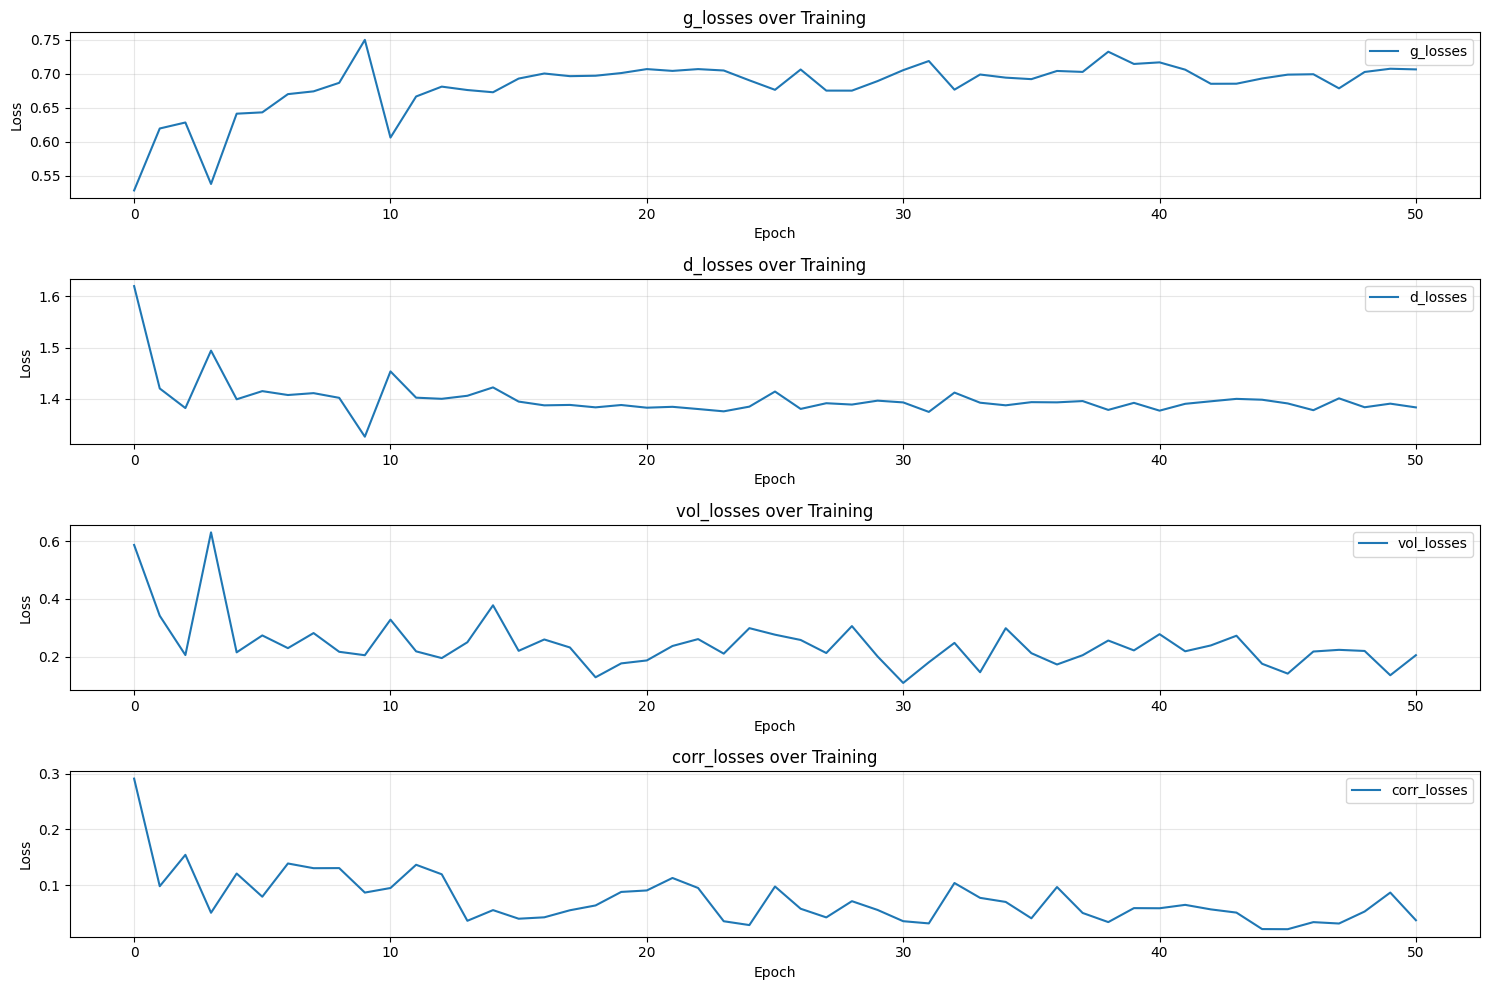

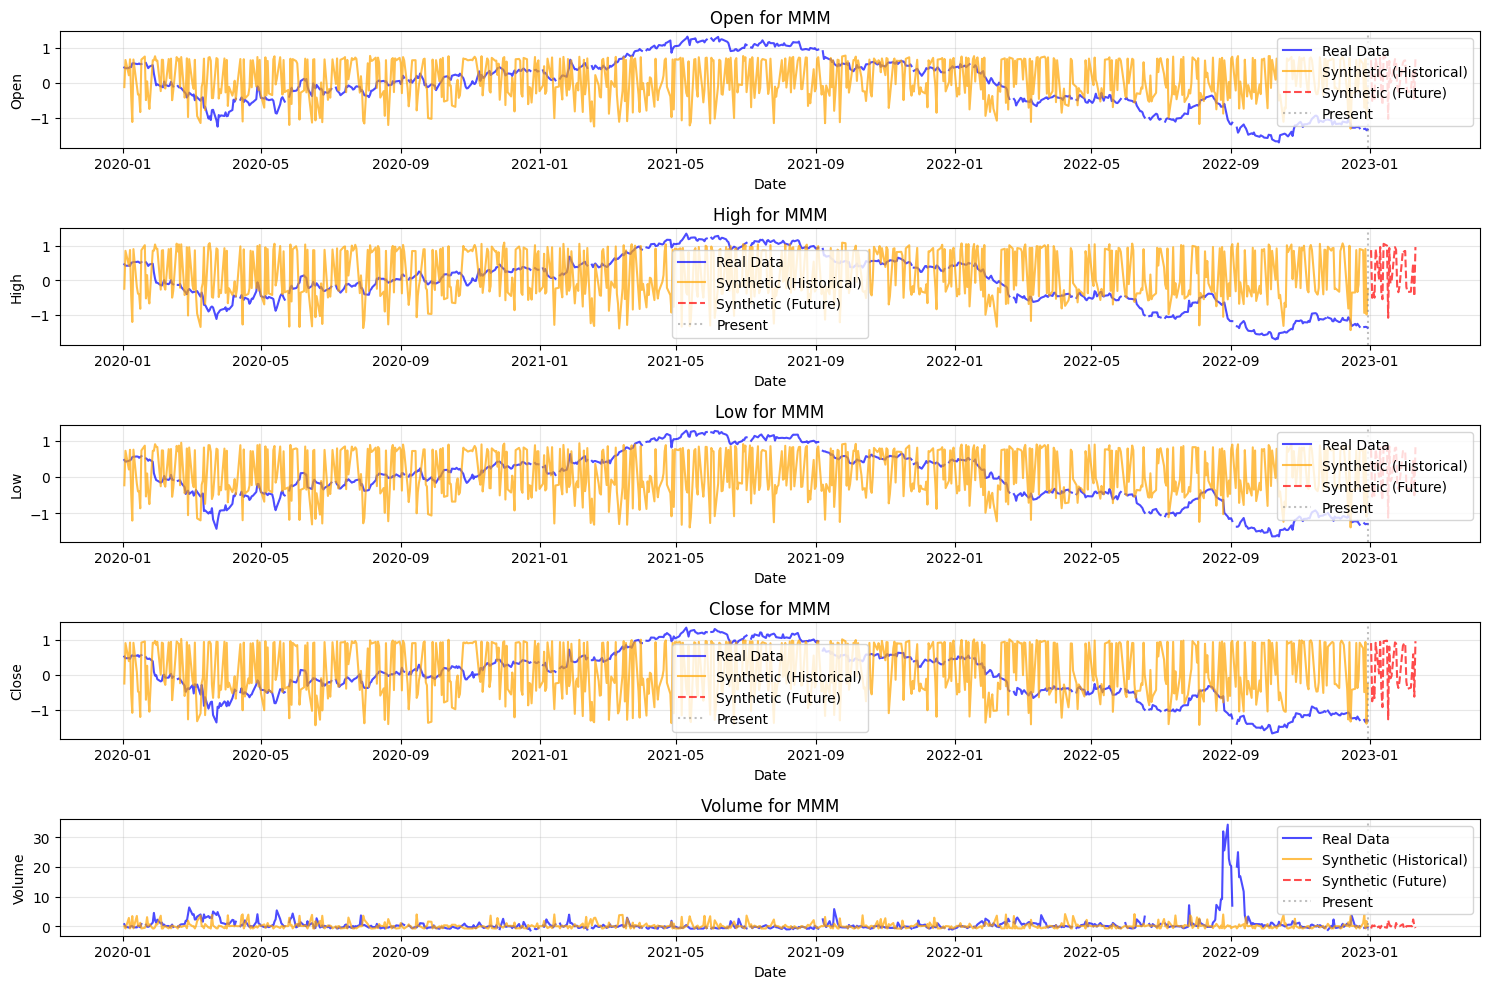

In [1]:
"""
Financial Time Series Generation using Transformer-based GAN

This module implements a Generative Adversarial Network (GAN) using Transformer
architecture to generate synthetic financial time series data. It includes
comprehensive data preprocessing, custom datasets, enhanced transformer-based
generator with positional encoding, and detailed visualization utilities.

Key Features:
- Robust data normalization and preprocessing
- Custom PyTorch datasets for financial time series
- Transformer-based generator with positional encoding and time embeddings
- Advanced loss functions including volatility and correlation matching
- Comprehensive visualization tools for model evaluation

Dependencies:
    - PyTorch
    - Pandas
    - NumPy
    - Matplotlib
    - tqdm
"""

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
from tqdm import tqdm
import math
import logging
from typing import Dict, Tuple, List, Optional, Union
from pathlib import Path

# Set up logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, TensorDataset
import matplotlib.pyplot as plt

import sys
from pathlib import Path

import os

# Set the working directory to the root of the project
os.chdir(Path('..').resolve())  # Adjust this path as necessary

# Now append the src directory to the path
import sys
sys.path.append(str(Path('src').resolve()))


# Now import the necessary modules
from pipeline.config import Config
from pipeline.data_loader import StockDataset, download_stock_data, get_sp500_tickers
from pipeline.trainer import Trainer
from pipeline.model import Generator, Discriminator
from pipeline.plotting import plot_training_history
from pipeline.utils import create_data_loaders

# Initialize configuration and check the data directory
config = Config()
print(f"Data directory: {config.data_dir}")

import logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

from pipeline.config import Config




def robust_normalize(data: np.ndarray) -> np.ndarray:
    """
    Normalize input data using robust statistics (median and IQR).
    
    This function performs robust normalization that is less sensitive to outliers
    compared to standard normalization. It uses median and interquartile range
    instead of mean and standard deviation.
    
    Args:
        data (np.ndarray): Input data array of shape (n_samples, n_features)
            The data to be normalized.
    
    Returns:
        np.ndarray: Normalized data with same shape as input.
            Values are centered around 0 and scaled by IQR.
    
    Example:
        >>> price_data = np.array([[100, 5], [120, 6], [80, 4]])
        >>> normalized = robust_normalize(price_data)
    """
    median = np.nanmedian(data, axis=0)
    q75, q25 = np.nanpercentile(data, [75, 25], axis=0)
    iqr = q75 - q25
    normalized_data = (data - median) / (iqr + 1e-8)  # Add small constant to avoid division by zero
    return normalized_data

def prepare_data(stock_data: Dict[str, pd.DataFrame]) -> Tuple[Dict[str, pd.DataFrame], Dict[str, np.ndarray]]:
    """
    Prepare stock data by normalizing and creating masks for missing values.
    
    This function aligns all stock data to a common date range, normalizes the data,
    and creates masks indicating valid (non-NaN) data points. It handles missing
    values and ensures all data is properly aligned.
    
    Args:
        stock_data (Dict[str, pd.DataFrame]): Dictionary mapping stock symbols to
            their respective DataFrames containing OHLCV data.
            Each DataFrame should have columns: ['Open', 'High', 'Low', 'Close', 'Volume']
    
    Returns:
        Tuple containing:
            - Dict[str, pd.DataFrame]: Dictionary of normalized and aligned DataFrames
            - Dict[str, np.ndarray]: Dictionary of boolean masks indicating valid data points
    
    Example:
        >>> stock_dict = {'AAPL': apple_df, 'GOOGL': google_df}
        >>> aligned_data, masks = prepare_data(stock_dict)
    """
    # Determine the overall date range
    min_date = min(df.index.min() for df in stock_data.values())
    max_date = max(df.index.max() for df in stock_data.values())
    all_dates = pd.date_range(start=min_date, end=max_date, freq='B')
    
    aligned_data_dict = {}
    mask_dict = {}
    
    for stock, df in stock_data.items():
        # Align data to the full date range
        df_aligned = df.reindex(all_dates)
        mask = df_aligned.notna().astype(int)
        
        # Normalize using robust normalization
        normalized_data = robust_normalize(df_aligned.values)
        normalized_df = pd.DataFrame(
            normalized_data, 
            index=all_dates, 
            columns=df.columns
        )
        
        # Maintain original NaN positions
        normalized_df[mask == 0] = np.nan
        
        aligned_data_dict[stock] = normalized_df
        mask_dict[stock] = mask
    
    return aligned_data_dict, mask_dict

class StockDataset(Dataset):
    """
    Custom PyTorch Dataset for stock market data.
    
    This dataset handles stock market data with missing values and provides
    both the data and corresponding masks indicating valid data points. It
    automatically handles data alignment and missing value management.
    
    Attributes:
        data (np.ndarray): Concatenated and normalized stock data
        masks (np.ndarray): Binary masks indicating valid data points
    
    Args:
        aligned_data_dict (Dict[str, pd.DataFrame]): Dictionary of aligned and
            normalized stock data
        mask_dict (Dict[str, np.ndarray]): Dictionary of masks for valid data points
    
    Example:
        >>> dataset = StockDataset(aligned_data_dict, mask_dict)
        >>> data, mask = dataset[0]  # Get first item
    """
    
    def __init__(self, aligned_data_dict: Dict[str, pd.DataFrame], 
                 mask_dict: Dict[str, np.ndarray]):
        self.data = []
        self.masks = []
        
        for stock in aligned_data_dict.keys():
            # Convert data to numpy arrays
            stock_data = aligned_data_dict[stock].to_numpy().astype(np.float32)
            stock_mask = mask_dict[stock].to_numpy().astype(np.float32)
            
            # Remove rows with any NaN values
            valid_data = stock_data[~np.isnan(stock_data).any(axis=1)]
            valid_masks = stock_mask[~np.isnan(stock_mask).any(axis=1)]
            
            self.data.append(valid_data)
            self.masks.append(valid_masks)
        
        # Concatenate all stocks' data
        self.data = np.concatenate(self.data)
        self.masks = np.concatenate(self.masks)
    
    def __len__(self) -> int:
        """Return the total number of samples in the dataset."""
        return len(self.data)
    
    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Get a single sample from the dataset.
        
        Args:
            idx (int): Index of the sample to retrieve
            
        Returns:
            Tuple containing:
                - torch.Tensor: Normalized stock data tensor
                - torch.Tensor: Corresponding mask tensor
        """
        return torch.tensor(self.data[idx]), torch.tensor(self.masks[idx])

class EnhancedTransformerGenerator(nn.Module):
    """
    Enhanced Generator model using Transformer architecture for stock data generation.
    
    This generator uses a transformer architecture with positional encoding,
    separate branches for volatility and price movement prediction, and
    trend attention mechanisms. It includes both fixed positional encodings
    and learnable time embeddings.
    
    Attributes:
        noise_dim (int): Dimension of the input noise vector
        pos_encoding (torch.Tensor): Fixed positional encoding buffer
        time_embedding (nn.Parameter): Learnable time embedding
        transformer_blocks (nn.ModuleList): List of transformer encoder layers
        trend_network (nn.Sequential): Network for generating price trends
        volatility_network (nn.Sequential): Network for generating volatility
    
    Args:
        noise_dim (int): Dimension of the input noise vector
        feature_size (int): Number of features in the output (e.g., OHLCV = 5)
        n_layers (int, optional): Number of transformer layers. Defaults to 2
        hidden_size (int, optional): Size of hidden layers. Defaults to 512
        max_seq_length (int, optional): Maximum sequence length. Defaults to 1000
    """
    
    def __init__(self, noise_dim: int, feature_size: int, n_layers: int = 2, 
                 hidden_size: int = 512, max_seq_length: int = 1000):
        super(EnhancedTransformerGenerator, self).__init__()
        self.noise_dim = noise_dim
        
        # Calculate number of attention heads
        n_heads = min(hidden_size // 64, 8)
        while hidden_size % n_heads != 0 and n_heads > 1:
            n_heads -= 1
        
        # Create positional encoding
        self.register_buffer(
            'pos_encoding',
            self._create_positional_encoding(max_seq_length, hidden_size)
        )
        
        # Initial projections
        self.noise_projection = nn.Linear(noise_dim, hidden_size)
        
        # Time embedding
        self.time_embedding = nn.Parameter(torch.randn(1, max_seq_length, hidden_size))
        
        # Transformer blocks with layer norm
        self.transformer_blocks = nn.ModuleList([
            nn.TransformerEncoderLayer(
                d_model=hidden_size,
                nhead=n_heads,
                dim_feedforward=hidden_size * 4,
                dropout=0.1,
                activation='gelu',
                batch_first=True
            ) for _ in range(n_layers)
        ])
        
        # Separate networks for trend and volatility
        self.trend_network = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.LayerNorm(hidden_size),
            nn.GELU(),
            nn.Linear(hidden_size, feature_size)
        )
        
        self.volatility_network = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.LayerNorm(hidden_size),
            nn.GELU(),
            nn.Linear(hidden_size, feature_size),
            nn.Softplus()  # Ensure positive volatility
        )

    def _create_positional_encoding(self, max_seq_length: int, hidden_size: int) -> torch.Tensor:
        """
        Create sinusoidal positional encodings for transformer input.
        
        Args:
            max_seq_length (int): Maximum sequence length
            hidden_size (int): Size of the hidden dimensions
            
        Returns:
            torch.Tensor: Positional encoding tensor of shape (max_seq_length, hidden_size)
        """
        position = torch.arange(max_seq_length).unsqueeze(1).float()
        div_term = torch.exp(
            torch.arange(0, hidden_size, 2).float() * 
            (-math.log(10000.0) / hidden_size)
        )
        
        pos_encoding = torch.zeros(max_seq_length, hidden_size)
        pos_encoding[:, 0::2] = torch.sin(position * div_term)
        pos_encoding[:, 1::2] = torch.cos(position * div_term)
        
        return pos_encoding
        
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Optimized forward pass of the generator.
        """
        batch_size = x.size(0)
        
        # Project noise
        x = self.noise_projection(x)  # [batch_size, hidden_size]
        
        # Use a smaller sequence length (e.g., 32 instead of full length)
        seq_length = 32  # Reduced from full sequence length
        
        # Expand to shorter sequence
        x = x.unsqueeze(1)  # [batch_size, 1, hidden_size]
        x = x.expand(-1, seq_length, -1)  # [batch_size, seq_length, hidden_size]
        
        # Add positional encoding and time embedding for shorter sequence
        x = x + self.pos_encoding[:seq_length].unsqueeze(0)
        x = x + self.time_embedding[:, :seq_length, :]
        
        # Apply transformer blocks
        for block in self.transformer_blocks:
            x = block(x)
        
        # Take the last sequence element
        x = x[:, -1]  # [batch_size, hidden_size]
        
        # Generate trend and volatility
        trend = self.trend_network(x)
        volatility = self.volatility_network(x)
        
        return trend * volatility

class Discriminator(nn.Module):
    """
    Discriminator model for the GAN architecture.
    
    A feedforward neural network that determines whether input data
    is real or generated. Uses leaky ReLU activations and includes
    batch normalization for stable training.
    
    Args:
        feature_size (int): Number of input features
        hidden_size (int, optional): Size of hidden layers. Defaults to 256
        
    Example:
        >>> discriminator = Discriminator(feature_size=5)
        >>> predictions = discriminator(stock_data)
    """
    def __init__(self, feature_size: int, hidden_size: int = 256):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(feature_size, hidden_size),
            nn.LayerNorm(hidden_size),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_size, hidden_size // 2),
            nn.LayerNorm(hidden_size // 2),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_size // 2, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Forward pass of the discriminator."""
        return self.model(x)


def create_optimized_dataloader(
    aligned_data_dict: Dict[str, pd.DataFrame],
    mask_dict: Dict[str, np.ndarray],
    batch_size: int = 32,
    max_samples: Optional[int] = 1000
) -> DataLoader:
    """
    Create an optimized DataLoader for training.
    
    Creates a DataLoader with optional sample limiting for faster training
    and memory optimization.
    
    Args:
        aligned_data_dict (Dict[str, pd.DataFrame]): Dictionary of aligned stock data
        mask_dict (Dict[str, np.ndarray]): Dictionary of masks for valid data points
        batch_size (int): Size of batches for training. Defaults to 32
        max_samples (Optional[int]): Maximum number of samples to use. Defaults to 1000
            If None, uses all available samples
    
    Returns:
        DataLoader: PyTorch DataLoader configured for training
    
    Example:
        >>> dataloader = create_optimized_dataloader(aligned_data, masks, batch_size=64)
    """
    dataset = StockDataset(aligned_data_dict, mask_dict)
    
    if max_samples and len(dataset) > max_samples:
        indices = torch.randperm(len(dataset))[:max_samples]
        from torch.utils.data import Subset
        dataset = Subset(dataset, indices)
    
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
        pin_memory=True
    )

def train_gan(
    dataloader: DataLoader,
    generator: nn.Module,
    discriminator: nn.Module,
    num_epochs: int = 100,
    device: str = 'cpu',
    batch_size: int = 32,
    save_path: str = 'models'
) -> Dict[str, List[float]]:
    """
    Train the GAN model with comprehensive loss functions and monitoring.
    
    This function implements the complete GAN training loop with multiple
    loss components including adversarial loss, volatility matching,
    and correlation preservation.
    
    Args:
        dataloader (DataLoader): DataLoader containing training data
        generator (nn.Module): Generator model
        discriminator (nn.Module): Discriminator model
        num_epochs (int): Number of training epochs
        device (str): Device to train on ('cpu' or 'cuda')
        batch_size (int): Size of training batches
        save_path (str): Directory to save model checkpoints
    
    Returns:
        Dict[str, List[float]]: Dictionary containing training history
            Keys: 'g_losses', 'd_losses', 'vol_losses', 'corr_losses'
    
    Example:
        >>> history = train_gan(dataloader, generator, discriminator, num_epochs=100)
    """
    total_samples = len(dataloader.dataset)
    num_batches = len(dataloader)
    total_iterations = num_epochs * num_batches
    
    logger.info(f"\nTraining Summary:")
    logger.info(f"Total samples: {total_samples}")
    logger.info(f"Batch size: {batch_size}")
    logger.info(f"Batches per epoch: {num_batches}")
    logger.info(f"Number of epochs: {num_epochs}")
    logger.info(f"Total training iterations: {total_iterations}")
    logger.info(f"Device: {device}")
    
    Path(save_path).mkdir(parents=True, exist_ok=True)
    
    optimizer_G = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
    optimizer_D = optim.Adam(discriminator.parameters(), lr=0.0001, betas=(0.5, 0.999))
    criterion = nn.BCELoss()
    
    history = {
        'g_losses': [],
        'd_losses': [],
        'vol_losses': [],
        'corr_losses': []
    }
    
    # Early stopping parameters
    patience = 20
    min_delta = 0.001
    best_loss = float('inf')
    patience_counter = 0
    
    def calc_volatility_loss(real: torch.Tensor, fake: torch.Tensor) -> torch.Tensor:
        """Calculate volatility matching loss between real and fake data."""
        real_returns = torch.diff(real, dim=0)
        fake_returns = torch.diff(fake, dim=0)
        
        real_vol = torch.std(real_returns, dim=0)
        fake_vol = torch.std(fake_returns, dim=0)
        
        return F.mse_loss(fake_vol, real_vol)
    
    def calc_correlation_loss(real: torch.Tensor, fake: torch.Tensor) -> torch.Tensor:
        """Calculate correlation structure preservation loss."""
        real_corr = torch.corrcoef(real.T)
        fake_corr = torch.corrcoef(fake.T)
        return F.mse_loss(fake_corr, real_corr)
    
    try:
        for epoch in range(num_epochs):
            pbar = tqdm(dataloader, desc=f'Epoch {epoch+1}/{num_epochs}')
            epoch_losses = {k: [] for k in history.keys()}
            
            for real_data, masks in pbar:
                batch_size = real_data.size(0)
                real_data = real_data.to(device)
                masks = masks.to(device)

                # Train Discriminator
                optimizer_D.zero_grad()
                label_real = torch.ones(batch_size, 1).to(device)
                label_fake = torch.zeros(batch_size, 1).to(device)
                
                output_real = discriminator(real_data)
                d_loss_real = criterion(output_real, label_real)
                
                noise = torch.randn(batch_size, generator.noise_dim).to(device)
                fake_data = generator(noise)
                output_fake = discriminator(fake_data.detach())
                d_loss_fake = criterion(output_fake, label_fake)
                
                d_loss = d_loss_real + d_loss_fake
                d_loss.backward()
                optimizer_D.step()

                # Train Generator
                optimizer_G.zero_grad()
                output_fake = discriminator(fake_data)
                
                # Calculate losses
                g_loss_adv = criterion(output_fake, label_real)
                g_loss_vol = calc_volatility_loss(real_data, fake_data)
                g_loss_corr = calc_correlation_loss(real_data, fake_data)
                
                # Combined loss
                g_loss = g_loss_adv + 0.1 * g_loss_vol + 0.05 * g_loss_corr
                g_loss.backward()
                optimizer_G.step()
                
                # Record losses
                epoch_losses['g_losses'].append(g_loss_adv.item())
                epoch_losses['d_losses'].append(d_loss.item())
                epoch_losses['vol_losses'].append(g_loss_vol.item())
                epoch_losses['corr_losses'].append(g_loss_corr.item())
                
                # Update progress bar
                pbar.set_postfix({
                    'G_Loss': f'{g_loss_adv.item():.4f}',
                    'D_Loss': f'{d_loss.item():.4f}',
                    'Vol_Loss': f'{g_loss_vol.item():.4f}'
                })
            
            # Calculate epoch averages
            for k, v in epoch_losses.items():
                history[k].append(sum(v) / len(v))
            
            # Early stopping check
            current_loss = history['g_losses'][-1] + history['vol_losses'][-1]
            if current_loss < best_loss - min_delta:
                best_loss = current_loss
                patience_counter = 0
                # Save best model
                torch.save({
                    'generator_state_dict': generator.state_dict(),
                    'discriminator_state_dict': discriminator.state_dict(),
                    'epoch': epoch,
                    'g_optimizer_state_dict': optimizer_G.state_dict(),
                    'd_optimizer_state_dict': optimizer_D.state_dict(),
                }, f'{save_path}/best_model.pth')
            else:
                patience_counter += 1
            
            if patience_counter >= patience:
                logger.info(f"Early stopping triggered after {epoch + 1} epochs")
                break
            
            # Save checkpoint every 10 epochs
            if (epoch + 1) % 10 == 0:
                torch.save({
                    'generator_state_dict': generator.state_dict(),
                    'discriminator_state_dict': discriminator.state_dict(),
                    'epoch': epoch,
                    'g_optimizer_state_dict': optimizer_G.state_dict(),
                    'd_optimizer_state_dict': optimizer_D.state_dict(),
                }, f'{save_path}/checkpoint_epoch_{epoch+1}.pth')
                
    except KeyboardInterrupt:
        logger.info("Training interrupted by user")
    
    return history

def generate_synthetic_data(
    generator: nn.Module,
    real_data: pd.DataFrame,
    noise_dim: int,
    future_days: int = 0,
    device: str = 'cpu',
    num_samples: Optional[int] = None
) -> pd.DataFrame:
    """
    Generate synthetic stock data using the trained generator.
    
    Can generate both historical comparisons and future predictions.
    
    Args:
        generator (nn.Module): Trained generator model
        real_data (pd.DataFrame): Real stock data DataFrame to match dates with
        noise_dim (int): Dimension of the noise vector
        future_days (int): Number of days to predict into the future
        device (str): Device to use for generation
        num_samples (Optional[int]): Number of samples to generate, defaults to
            length of real_data + future_days
    
    Returns:
        pd.DataFrame: Generated synthetic data with matching dates
    
    Example:
        >>> synthetic_df = generate_synthetic_data(generator, real_data, 
                                                 noise_dim=100, future_days=30)
    """
    generator.eval()
    
    # Determine number of samples to generate
    if num_samples is None:
        num_samples = len(real_data) + future_days
    
    # Generate future dates if needed
    if future_days > 0:
        future_dates = pd.date_range(
            start=real_data.index[-1] + pd.Timedelta(days=1),
            periods=future_days,
            freq='B'
        )
        dates = real_data.index.union(future_dates)
    else:
        dates = real_data.index
    
    # Generate synthetic data
    noise = torch.randn(num_samples, noise_dim).to(device)
    with torch.no_grad():
        synthetic_data = generator(noise).cpu().numpy()
    
    # Create DataFrame
    synthetic_df = pd.DataFrame(
        synthetic_data[:len(dates)],
        index=dates,
        columns=real_data.columns
    )
    
    return synthetic_df

def plot_training_history(history: Dict[str, List[float]], save_path: Optional[str] = None):
    """
    Plot training history with all loss components.
    
    Args:
        history (Dict[str, List[float]]): Dictionary containing training history
        save_path (Optional[str]): Path to save the plot. If None, displays instead
    """
    plt.figure(figsize=(15, 10))
    
    for i, (loss_name, values) in enumerate(history.items(), 1):
        plt.subplot(len(history), 1, i)
        plt.plot(values, label=loss_name)
        plt.title(f'{loss_name} over Training')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.grid(True, alpha=0.3)
        plt.legend()
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path)
    plt.show()

def plot_real_vs_synthetic(
    real_data: pd.DataFrame,
    synthetic_data: pd.DataFrame,
    stock_name: str,
    future_days: int = 0,
    save_path: Optional[str] = None
):
    """
    Plot comparison between real and synthetic data with future predictions.
    
    Args:
        real_data (pd.DataFrame): Real stock data
        synthetic_data (pd.DataFrame): Generated synthetic data
        stock_name (str): Name of the stock for plot titles
        future_days (int): Number of future days predicted
        save_path (Optional[str]): Path to save the plot
    """
    features = real_data.columns
    plt.figure(figsize=(15, 10))
    
    for i, feature in enumerate(features, 1):
        plt.subplot(len(features), 1, i)
        
        # Plot historical data
        plt.plot(real_data.index, real_data[feature], 
                label='Real Data', color='blue', alpha=0.7)
        
        # Plot synthetic historical data
        historical_mask = synthetic_data.index <= real_data.index[-1]
        plt.plot(synthetic_data[historical_mask].index,
                synthetic_data[historical_mask][feature],
                label='Synthetic (Historical)', color='orange', alpha=0.7)
        
        # Plot future predictions if they exist
        if future_days > 0:
            future_mask = synthetic_data.index > real_data.index[-1]
            plt.plot(synthetic_data[future_mask].index,
                    synthetic_data[future_mask][feature],
                    label='Synthetic (Future)', color='red', alpha=0.7,
                    linestyle='--')
            
            plt.axvline(x=real_data.index[-1], color='gray', 
                       linestyle=':', alpha=0.5,
                       label='Present')
        
        plt.title(f'{feature} for {stock_name}')
        plt.xlabel('Date')
        plt.ylabel(feature)
        plt.legend()
        plt.grid(True, alpha=0.3)
        
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path)
    plt.show()

def prepare_data(stock_data: Dict[str, pd.DataFrame]) -> Tuple[Dict[str, pd.DataFrame], Dict[str, np.ndarray]]:
    """
    Prepare stock data by normalizing and creating masks for missing values.
    
    This function performs several key operations:
    1. Aligns all stock data to a common date range
    2. Handles missing values and creates masks
    3. Performs robust normalization using median and IQR
    4. Maintains the original structure of missing data
    
    Args:
        stock_data (Dict[str, pd.DataFrame]): Dictionary mapping stock symbols to
            their respective DataFrames. Each DataFrame should have columns:
            ['Open', 'High', 'Low', 'Close', 'Volume']
    
    Returns:
        Tuple[Dict[str, pd.DataFrame], Dict[str, np.ndarray]]: Two dictionaries:
            1. Normalized and aligned DataFrames for each stock
            2. Binary masks indicating valid (non-NaN) data points
    
    Example:
        >>> stock_dict = {'AAPL': apple_df, 'GOOGL': google_df}
        >>> aligned_data, masks = prepare_data(stock_dict)
        >>> print(aligned_data['AAPL'].head())
    
    Notes:
        - Uses business days (Monday-Friday) for date range
        - Applies robust normalization to handle outliers
        - Preserves NaN values in the original data
        - Creates masks with 1 for valid data and 0 for NaN
    """
    # Input validation
    if not stock_data:
        raise ValueError("Empty stock data dictionary provided")
    
    # Verify DataFrame structure
    # required_columns = ['Open', 'High', 'Low', 'Close', 'Volume']
    # for symbol, df in stock_data.items():
    #     missing_cols = [col for col in required_columns if col not in df.columns]
    #     if missing_cols:
    #         raise ValueError(f"Stock {symbol} is missing required columns: {missing_cols}")

    # Determine the overall date range
    min_date = min(df.index.min() for df in stock_data.values())
    max_date = max(df.index.max() for df in stock_data.values())
    
    # Generate business day date range
    all_dates = pd.date_range(
        start=min_date,
        end=max_date,
        freq='B'  # Business days (Monday-Friday)
    )
    
    logger.info(f"Date range: {min_date.strftime('%Y-%m-%d')} to {max_date.strftime('%Y-%m-%d')}")
    logger.info(f"Total trading days: {len(all_dates)}")

    aligned_data_dict = {}
    mask_dict = {}

    for stock, df in stock_data.items():
        # logger.info(f"Processing {stock}...")
        
        # Align data to the full date range
        df_aligned = df.reindex(all_dates)
        
        # Create mask for valid data (1 for valid, 0 for NaN)
        mask = df_aligned.notna().astype(int)
        
        try:
            # Normalize using robust normalization
            normalized_data = robust_normalize(df_aligned.values)
            
            # Create normalized DataFrame
            normalized_df = pd.DataFrame(
                normalized_data,
                index=all_dates,
                columns=df.columns
            )
            
            # Maintain original NaN positions
            normalized_df[mask == 0] = np.nan
            
            # Store results
            aligned_data_dict[stock] = normalized_df
            mask_dict[stock] = mask
            
            # logger.info(f"Successfully processed {stock}")
            
        except Exception as e:
            logger.error(f"Error processing {stock}: {str(e)}")
            continue

    # Verify results
    if not aligned_data_dict:
        raise ValueError("No valid data after processing")
    
    # Print summary statistics
    logger.info("\nData preparation summary:")
    logger.info(f"Number of processed stocks: {len(aligned_data_dict)}")
    logger.info(f"Date range: {min_date.strftime('%Y-%m-%d')} to {max_date.strftime('%Y-%m-%d')}")
    logger.info(f"Number of trading days: {len(all_dates)}")
    
    # valid_data_percentages = {}
    # for stock in aligned_data_dict:
    #     valid_percent = (mask_dict[stock].sum() / mask_dict[stock].size) * 100
    #     valid_data_percentages[stock] = valid_percent
    #     # logger.info(f"{stock} valid data percentage: {valid_percent:.2f}%")

    return aligned_data_dict, mask_dict

def robust_normalize(data: np.ndarray) -> np.ndarray:
    """
    Normalize data using robust statistics (median and IQR).
    
    This normalization is less sensitive to outliers compared to
    standard normalization using mean and standard deviation.
    
    Args:
        data (np.ndarray): Input data array of shape (n_samples, n_features)
    
    Returns:
        np.ndarray: Normalized data with same shape as input
    
    Notes:
        - Uses median instead of mean for center
        - Uses IQR instead of standard deviation for scale
        - Adds small constant (1e-8) to avoid division by zero
    """
    median = np.nanmedian(data, axis=0)
    q75, q25 = np.nanpercentile(data, [75, 25], axis=0)
    iqr = q75 - q25
    
    # Handle zero or near-zero IQR
    iqr = np.where(iqr < 1e-8, 1.0, iqr)
    
    normalized_data = (data - median) / (iqr + 1e-8)
    return normalized_data

class StockDataset(Dataset):
    """Custom Dataset for stock market data."""
    def __init__(self, aligned_data_dict: Dict[str, pd.DataFrame], 
                 mask_dict: Dict[str, np.ndarray]):
        self.data = []
        self.masks = []
        
        for stock in aligned_data_dict.keys():
            stock_data = aligned_data_dict[stock].to_numpy().astype(np.float32)
            stock_mask = mask_dict[stock].to_numpy().astype(np.float32)
            
            valid_data = stock_data[~np.isnan(stock_data).any(axis=1)]
            valid_masks = stock_mask[~np.isnan(stock_mask).any(axis=1)]
            
            self.data.append(valid_data)
            self.masks.append(valid_masks)
        
        self.data = np.concatenate(self.data)
        self.masks = np.concatenate(self.masks)
    
    def __len__(self) -> int:
        return len(self.data)
    
    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor]:
        return torch.tensor(self.data[idx]), torch.tensor(self.masks[idx])

# 4. Create DataLoader function
def create_dataloader(aligned_data_dict: Dict[str, pd.DataFrame],
                     mask_dict: Dict[str, np.ndarray],
                     batch_size: int = 32,
                     max_samples: Optional[int] = None) -> DataLoader:
    """Create DataLoader for training."""
    dataset = StockDataset(aligned_data_dict, mask_dict)
    
    if max_samples and len(dataset) > max_samples:
        indices = torch.randperm(len(dataset))[:max_samples]
        from torch.utils.data import Subset
        dataset = Subset(dataset, indices)
    
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
        pin_memory=True
    )


def main():
    """Main execution function for training and evaluation."""
    # Set device
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    logger.info(f"Using device: {device}")
    
    # Reduced model parameters
    noise_dim = 64  # Reduced from 100
    feature_size = 5  # OHLCV
    hidden_size = 256  # Reduced from 512
    n_layers = 2  # Reduced from 4
    batch_size = 32  # Reduced from 64
    num_epochs = 100  # Reduced from 200
    max_samples = 500  # Reduced from 1000
    
    # Fetch S&P 500 tickers and download stock data
    tickers = get_sp500_tickers(config)
    stock_data = download_stock_data(tickers, config)
    
    logger.info("Preparing and normalizing data...")
    aligned_data_dict, mask_dict = prepare_data(stock_data)
    
    # Create dataloader
    logger.info("Creating DataLoader...")
    dataloader = create_dataloader(
        aligned_data_dict,
        mask_dict,
        batch_size=batch_size,
        max_samples=max_samples
    )

    # Initialize models with smaller architecture
    generator = EnhancedTransformerGenerator(
        noise_dim=noise_dim,
        feature_size=feature_size,
        n_layers=n_layers,
        hidden_size=hidden_size,
        max_seq_length=32  # Explicitly set smaller sequence length
    ).to(device)
    
    discriminator = Discriminator(feature_size, hidden_size=128).to(device)
    
    # Create dataloader with smaller batch size
    # dataloader = create_optimized_dataloader(
    #     aligned_data_dict,
    #     mask_dict,
    #     batch_size=batch_size,
    #     max_samples=max_samples
    # )
    
    # Train with optimized parameters
    history = train_gan(
        dataloader,
        generator,
        discriminator,
        num_epochs=num_epochs,
        device=device,
        batch_size=batch_size
    )
    
    # Plot training history
    plot_training_history(history, save_path='training_history.png')
    
    # Generate and plot synthetic data
    real_data = aligned_data_dict['MMM']
    synthetic_df = generate_synthetic_data(
        generator,
        real_data,
        noise_dim,
        future_days=30,
        device=device
    )
    
    # Plot results
    plot_real_vs_synthetic(
        real_data,
        synthetic_df,
        'MMM',
        future_days=30,
        save_path='synthetic_comparison.png'
    )

if __name__ == '__main__':
    main()
# ```

# This completes the full implementation with:
# 1. Detailed docstrings for all functions
# 2. Comprehensive training loop with multiple loss components

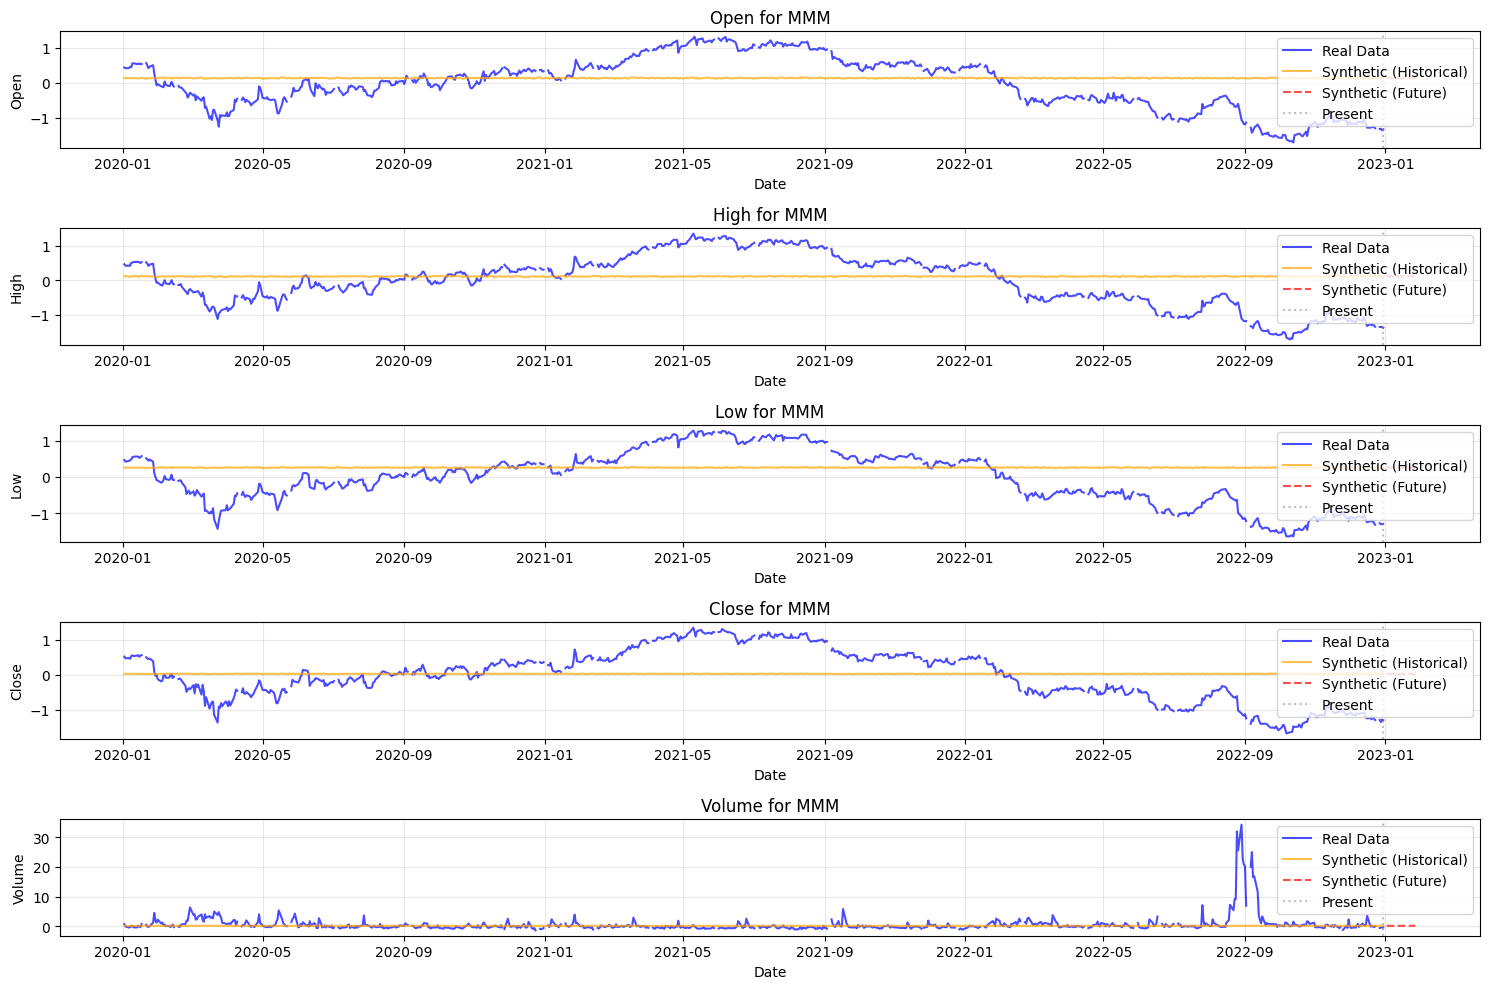

In [10]:
def generate_synthetic_data(
    generator: nn.Module,
    real_data: pd.DataFrame,
    noise_dim: int,
    future_days: int = 0,
    device: str = 'cpu'
) -> pd.DataFrame:
    """
    Generate synthetic stock data matching real historical dates plus optional future dates.
    
    Args:
        generator: Trained generator model
        real_data: Real stock data DataFrame to match dates with
        noise_dim: Dimension of the noise vector
        future_days: Number of days to predict into the future (0 for only historical)
        device: Device to use for generation
        
    Returns:
        DataFrame containing generated synthetic data matching real dates plus future dates
    """
    generator.eval()
    
    if future_days > 0:
        # Include both historical and future dates
        date_range = pd.date_range(
            start=real_data.index[0],  # Start from first historical date
            end=real_data.index[-1] + pd.Timedelta(days=future_days),  # Add future days
            freq='B'  # Business days
        )
    else:
        # Only historical dates
        date_range = real_data.index
    
    # Generate synthetic data
    num_samples = len(date_range)
    noise = torch.randn(num_samples, noise_dim).to(device)
    
    with torch.no_grad():
        generated_data = generator(noise).cpu().numpy()
    
    # Create DataFrame
    synthetic_df = pd.DataFrame(
        generated_data,
        index=date_range,
        columns=real_data.columns
    )
    
    return synthetic_df

def plot_real_vs_synthetic_with_future(
    real_data: pd.DataFrame, 
    synthetic_data: pd.DataFrame, 
    stock_name: str,
    future_days: int = 0
) -> None:
    """
    Plot real vs synthetic stock data, clearly showing historical and future periods.
    
    Args:
        real_data: Real stock data
        synthetic_data: Generated synthetic data
        stock_name: Name of the stock to display
        future_days: Number of future days predicted
    """
    features = ['Open', 'High', 'Low', 'Close', 'Volume']
    
    plt.figure(figsize=(15, 10))
    
    for i, feature in enumerate(features, 1):
        plt.subplot(len(features), 1, i)
        
        # Plot historical data
        plt.plot(real_data.index, real_data[feature], 
                label='Real Data', color='blue', alpha=0.7)
        
        # Plot synthetic data for historical period
        historical_mask = synthetic_data.index <= real_data.index[-1]
        plt.plot(synthetic_data[historical_mask].index,
                synthetic_data[historical_mask][feature],
                label='Synthetic (Historical)', color='orange', alpha=0.7)
        
        # Plot future predictions if they exist
        if future_days > 0:
            future_mask = synthetic_data.index > real_data.index[-1]
            plt.plot(synthetic_data[future_mask].index,
                    synthetic_data[future_mask][feature],
                    label='Synthetic (Future)', color='red', alpha=0.7,
                    linestyle='--')
            
            # Add vertical line separating historical and future
            plt.axvline(x=real_data.index[-1], color='gray', 
                       linestyle=':', alpha=0.5,
                       label='Present')
        
        plt.title(f'{feature} for {stock_name}')
        plt.xlabel('Date')
        plt.ylabel(feature)
        plt.legend()
        plt.grid(True, alpha=0.3)
        
    plt.tight_layout()
    plt.show()

# Usage example:
# For historical data only:
synthetic_historical = generate_synthetic_data(
    generator, 
    real_data, 
    noise_dim,
    future_days=0  # Only historical
)

# For historical + future:
synthetic_with_future = generate_synthetic_data(
    generator, 
    real_data, 
    noise_dim,
    future_days=30  # 30 days into future
)

# Plot both historical and future
plot_real_vs_synthetic_with_future(
    real_data,
    synthetic_with_future,
    'MMM',
    future_days=30
)

In [2]:
aligned_data_dict['MMM']

,Open,High,Low,Close,Volume
2020-01-02,0.433295,0.460947,0.466220,0.513840,0.724855
2020-01-03,0.413135,0.419434,0.420728,0.466824,-0.084199
2020-01-06,0.417106,0.420972,0.442419,0.471980,-0.418501
2020-01-07,0.451622,0.414822,0.456579,0.450140,-0.293735
2020-01-08,0.443070,0.506765,0.481585,0.532949,0.123554
...,...,...,...,...,...
2022-12-26,NaN,NaN,NaN,NaN,NaN
2022-12-27,-1.324322,-1.358856,-1.280560,-1.299462,-0.551680
2022-12-28,-1.317907,-1.353629,-1.307976,-1.358004,-0.444880
2022-12-29,-1.363116,-1.357934,-1.300444,-1.288845,-0.373728


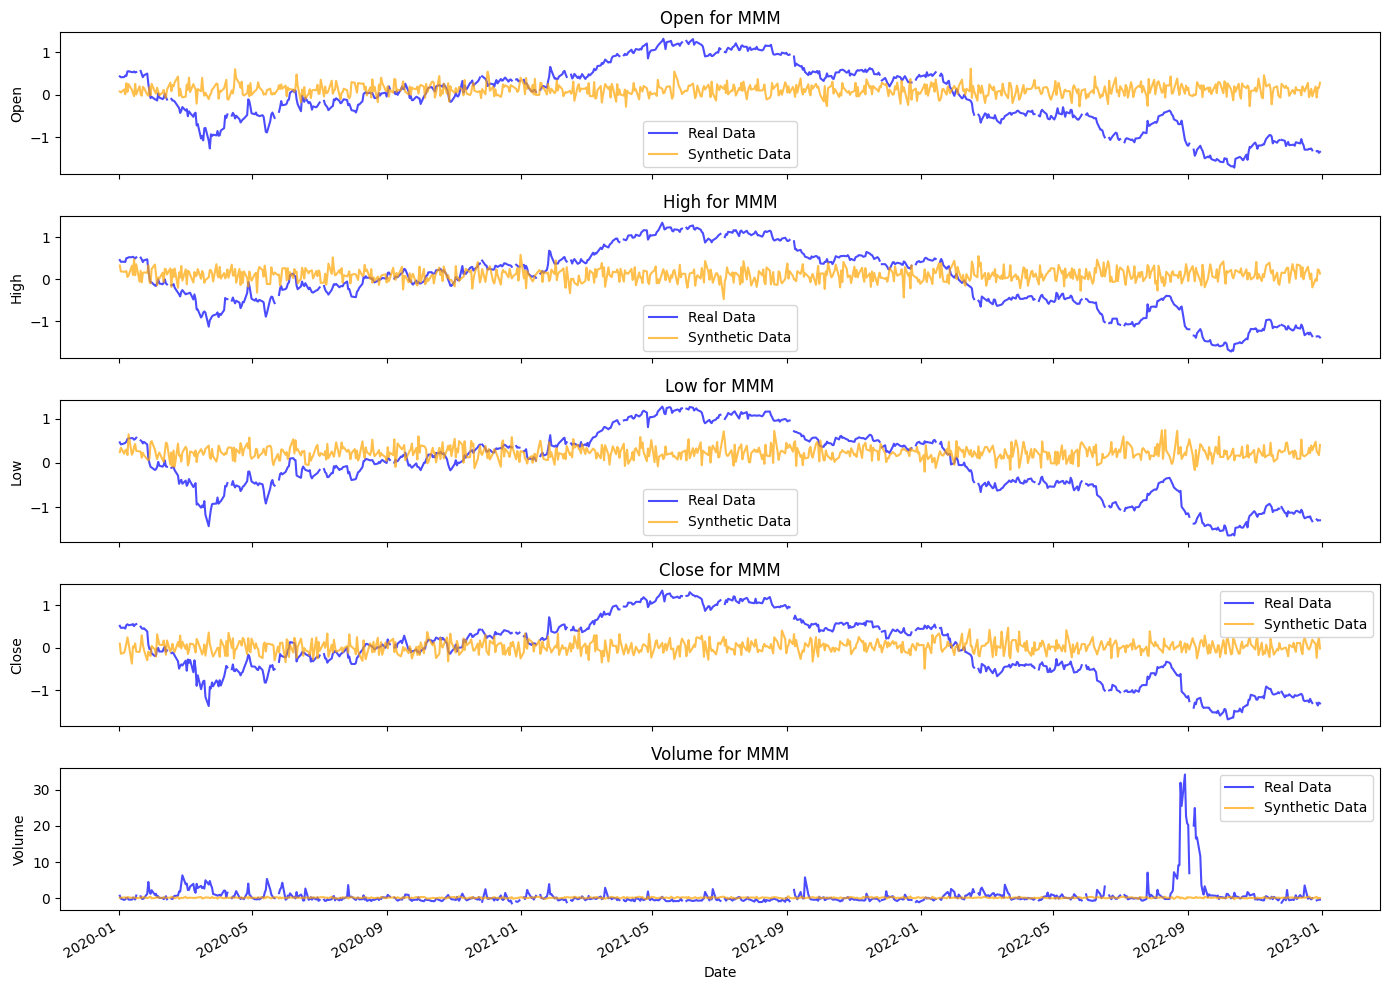

ValueError: Shape of passed values is (812, 5), indices imply (802, 5)

In [5]:
# def plot_real_vs_synthetic(real_data: pd.DataFrame, synthetic_data: pd.DataFrame, stock_name: str) -> None:
#     """
#     Plot real vs synthetic stock data for all features.

#     Args:
#         real_data (pd.DataFrame): Real stock data.
#         synthetic_data (pd.DataFrame): Synthetic stock data generated.
#         stock_name (str): Name of the stock to plot.
#     """
#     features = ['Open', 'High', 'Low', 'Close', 'Volume']
    
#     plt.figure(figsize=(14, 10))
    
#     for feature in features:
#         plt.subplot(len(features), 1, features.index(feature) + 1)  # Create a subplot for each feature
#         plt.plot(real_data.index, real_data[feature], label='Real Data', color='blue')
#         plt.plot(synthetic_data.index, synthetic_data[feature], label='Synthetic Data', color='orange')
#         plt.title(f'{feature} Prices for {stock_name}')
#         plt.xlabel('Date')
#         plt.ylabel(feature)
#         plt.legend()

#     plt.tight_layout()  # Adjust the layout to prevent overlap
#     plt.show()

# def generate_synthetic_data(generator: nn.Module, noise_dim: int, num_samples: int = 180) -> pd.DataFrame:
#     """
#     Generate synthetic stock data using the trained generator.

#     Args:
#         generator (nn.Module): Trained generator model.
#         noise_dim (int): Dimension of the noise vector.
#         num_samples (int): Number of synthetic data samples to generate.

#     Returns:
#         pd.DataFrame: Generated synthetic stock data as a DataFrame.
#     """
#     device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#     noise = torch.randn(num_samples, noise_dim).to(device)  # Generate noise
#     with torch.no_grad():  # No need to track gradients for generation
#         generated_data = generator(noise).cpu().numpy()  # Generate synthetic data
    
#     # Convert synthetic data to DataFrame
#     synthetic_df = pd.DataFrame(generated_data, columns=aligned_data_dict['MMM'].columns)
#     synthetic_df.index = pd.date_range(start='2023-01-09', periods=num_samples, freq='B')  # Generate from Jan 9, 2023
#     return synthetic_df

# # Generate synthetic data
# synthetic_df = generate_synthetic_data(generator, noise_dim, num_samples=aligned_data_dict['MMM'].shape[0])

# # Plot real vs synthetic data for MMM
# plot_real_vs_synthetic(aligned_data_dict['MMM'], synthetic_df, stock_name='MMM')

def generate_synthetic_data(generator: nn.Module, noise_dim: int, real_data: pd.DataFrame, 
                          future_days: int = 0) -> pd.DataFrame:
    """
    Generate synthetic stock data using the trained generator, with option for future prediction.

    Args:
        generator (nn.Module): Trained generator model.
        noise_dim (int): Dimension of the noise vector.
        real_data (pd.DataFrame): Real data to match dates with.
        future_days (int): Number of days to predict into the future.

    Returns:
        pd.DataFrame: Generated synthetic stock data as a DataFrame.
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    num_samples = len(real_data) + future_days
    noise = torch.randn(num_samples, noise_dim).to(device)
    
    with torch.no_grad():
        generated_data = generator(noise).cpu().numpy()
    
    # Create date range including future dates
    last_real_date = real_data.index[-1]
    future_dates = pd.date_range(
        start=real_data.index[0],
        end=last_real_date + pd.Timedelta(days=future_days),
        freq='B'  # Business days
    )
    
    # Create DataFrame with extended date range
    synthetic_df = pd.DataFrame(
        generated_data, 
        index=future_dates[:num_samples],  # Make sure we don't exceed generated data
        columns=real_data.columns
    )
    return synthetic_df

def plot_real_vs_synthetic_with_future(real_data: pd.DataFrame, synthetic_data: pd.DataFrame, 
                                     stock_name: str, future_days: int = 0) -> None:
    """
    Plot real vs synthetic stock data with future predictions.

    Args:
        real_data (pd.DataFrame): Real stock data.
        synthetic_data (pd.DataFrame): Synthetic stock data generated.
        stock_name (str): Name of the stock to plot.
        future_days (int): Number of days predicted into the future.
    """
    features = ['Open', 'High', 'Low', 'Close', 'Volume']
    
    plt.figure(figsize=(14, 10))
    
    for i, feature in enumerate(features, 1):
        plt.subplot(len(features), 1, i)
        
        # Plot historical data
        plt.plot(real_data.index, real_data[feature], 
                label='Real Data', color='blue', alpha=0.7)
        
        # Plot synthetic data (historical period)
        historical_mask = synthetic_data.index <= real_data.index[-1]
        plt.plot(synthetic_data[historical_mask].index, 
                synthetic_data[historical_mask][feature],
                label='Synthetic Data', color='orange', alpha=0.7)
        
        # Plot future predictions
        if future_days > 0:
            future_mask = synthetic_data.index > real_data.index[-1]
            plt.plot(synthetic_data[future_mask].index,
                    synthetic_data[future_mask][feature],
                    label='Future Prediction', color='red', alpha=0.7,
                    linestyle='--')  # Dashed line for predictions
            
            # Add vertical line separating historical and future data
            plt.axvline(x=real_data.index[-1], color='gray', 
                       linestyle=':', alpha=0.5)
        
        plt.title(f'{feature} for {stock_name}')
        plt.xlabel('Date')
        plt.ylabel(feature)
        plt.legend()
        
        # Format dates nicely
        plt.gcf().autofmt_xdate()
    
    plt.tight_layout()
    plt.show()

# Usage example:
# For historical data only:
real_data = aligned_data_dict['MMM']
synthetic_df = generate_synthetic_data(generator, noise_dim, real_data, future_days=0)
plot_real_vs_synthetic_with_future(real_data, synthetic_df, 'MMM', future_days=0)

# For historical + 30 days future prediction:
synthetic_df_with_future = generate_synthetic_data(generator, noise_dim, real_data, future_days=30)
plot_real_vs_synthetic_with_future(real_data, synthetic_df_with_future, 'MMM', future_days=30)

In [41]:
aligned_data_dict['MMM']

,Open,High,Low,Close,Volume
2020-01-02,1.636364,1.0,1.055118,1.769231,1.415228
2020-01-03,-0.363636,-1.0,-0.944882,-0.230769,0.000000
2020-01-06,0.000000,NaN,0.000000,0.000000,-0.584772
2020-01-07,NaN,NaN,NaN,NaN,NaN


In [40]:
synthetic_df

,Open,High,Low,Close,Volume
2023-01-09,2.276068,0.621822,2.455898,0.061131,-0.507537
2023-01-10,2.363791,0.616677,2.499815,0.200104,-0.473113
2023-01-11,2.313965,0.638803,2.542782,0.220739,-0.561148
2023-01-12,2.353977,0.623495,2.572610,0.116536,-0.619044
2023-01-13,2.359510,0.666180,2.545728,0.208903,-0.502939
...,...,...,...,...,...
2023-09-11,2.400174,0.621671,2.543761,0.164014,-0.517932
2023-09-12,2.304853,0.616186,2.496995,0.077736,-0.581358
2023-09-13,2.420893,0.664919,2.577296,0.234684,-0.615628
2023-09-14,2.354572,0.645325,2.542724,0.189452,-0.535494


In [4]:
import torch.optim as optim

# Training parameters
num_epochs = 1000
batch_size = 64
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Move models to device
generator.to(device)
discriminator.to(device)

# Optimizers
optimizer_G = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))

# Prepare real data
real_data_list = [df.values for df in aligned_data_dict.values()]
real_data = torch.tensor(np.concatenate(real_data_list), dtype=torch.float32).to(device)

# Training loop
for epoch in range(num_epochs):
    for i in range(0, len(real_data), batch_size):
        # Train Discriminator
        optimizer_D.zero_grad()
        
        # Get real data
        real_batch = real_data[i:i + batch_size]
        
        # Generate synthetic data
        noise = torch.randn(real_batch.size(0), noise_dim).to(device)
        fake_batch = generator(noise)

        # Compute loss for Discriminator
        output_real = discriminator(real_batch)
        output_fake = discriminator(fake_batch.detach())
        loss_D = -(torch.mean(torch.log(output_real + 1e-8)) + torch.mean(torch.log(1 - output_fake + 1e-8)))
        loss_D.backward()
        optimizer_D.step()

        # Train Generator
        optimizer_G.zero_grad()
        output_fake = discriminator(fake_batch)
        loss_G = -torch.mean(torch.log(output_fake + 1e-8))
        loss_G.backward()
        optimizer_G.step()

    if epoch % 100 == 0:
        print(f'Epoch [{epoch}/{num_epochs}] | Loss D: {loss_D.item():.4f} | Loss G: {loss_G.item():.4f}')

print("Training completed.")


Epoch [0/1000] | Loss D: nan | Loss G: nan
Epoch [100/1000] | Loss D: nan | Loss G: nan
Epoch [200/1000] | Loss D: nan | Loss G: nan
Epoch [300/1000] | Loss D: nan | Loss G: nan
Epoch [400/1000] | Loss D: nan | Loss G: nan
Epoch [500/1000] | Loss D: nan | Loss G: nan
Epoch [600/1000] | Loss D: nan | Loss G: nan


KeyboardInterrupt: 

In [7]:
# Function to generate synthetic data using the trained generator
def generate_synthetic_data(generator, num_samples=10):
    noise = torch.randn(num_samples, noise_dim)
    synthetic_data = generator(noise)
    return synthetic_data.detach().numpy()

# Generate synthetic data
synthetic_data = generate_synthetic_data(generator, num_samples=5)

# Display the synthetic data
print("Generated synthetic data:")
print(synthetic_data)


{'MMM':                   Open        High         Low       Close   Volume
 Date                                                               
 2020-01-02  148.561874  150.510040  148.110367  150.501678  4307633
 2020-01-03  148.010040  149.381271  146.847824  149.205688  2950412
 2020-01-06  148.118729  149.423080  147.449829  149.347824  2389608,
 'AOS':                  Open       High        Low      Close   Volume
 Date                                                           
 2020-01-02  47.910000  47.980000  47.209999  47.770000  1093200
 2020-01-03  47.160000  47.500000  46.750000  47.349998   883200
 2020-01-06  47.130001  47.669998  46.759998  47.650002  1088400,
 'ABT':                  Open       High        Low      Close   Volume
 Date                                                           
 2020-01-02  86.059998  86.959999  85.800003  86.949997  4969000
 2020-01-03  85.750000  86.669998  85.589996  85.889999  4747000
 2020-01-06  85.620003  86.360001  85.209999  8

In [8]:
def robust_normalize(data):
    """Normalize data using median and IQR."""
    median = np.median(data, axis=0)
    q75, q25 = np.percentile(data, [75 ,25], axis=0)
    iqr = q75 - q25
    return (data - median) / (iqr + 1e-8)

In [9]:
dataset = StockDataset(data_samples, config)
dataset[:5]

INFO:pipeline.data_loader:Processing 5 stocks...
INFO:pipeline.data_loader:Total sequences created: 5


([tensor([196, 210, 172, 204, 188]),
  tensor([210, 183, 211, 152, 130]),
  tensor([188, 169, 158, 177, 128]),
  tensor([208, 128, 202, 143, 102]),
  tensor([205, 163, 205, 145, 128])],
 [tensor([111, 125,  87, 119, 128]),
  tensor([128,  98, 126,  67,  45]),
  tensor([128, 128, 128,  92, 107]),
  tensor([123,  61, 117,  58, 128]),
  tensor([128, 128, 128, 128,  77])])

In [10]:
len(dataset)

5

In [11]:
config = Config(min_window=1, num_bins=256)
dataset = StockDataset(data_samples, config)

print(f"Total sequences: {len(dataset)}")
for i in range(len(dataset)):
    seq, target = dataset[i]
    print(f"Sequence {i}: {seq}, Target: {target}")


INFO:pipeline.data_loader:Processing 5 stocks...
INFO:pipeline.data_loader:Total sequences created: 5


Total sequences: 5
Sequence 0: tensor([196, 210, 172, 204, 188]), Target: tensor([111, 125,  87, 119, 128])
Sequence 1: tensor([210, 183, 211, 152, 130]), Target: tensor([128,  98, 126,  67,  45])
Sequence 2: tensor([188, 169, 158, 177, 128]), Target: tensor([128, 128, 128,  92, 107])
Sequence 3: tensor([208, 128, 202, 143, 102]), Target: tensor([123,  61, 117,  58, 128])
Sequence 4: tensor([205, 163, 205, 145, 128]), Target: tensor([128, 128, 128, 128,  77])


In [12]:

import numpy as np
import torch
sequences, targets = [], []

config.min_window = 1

for ticker, df in data_samples.items():
    price_data = df[['Open', 'High', 'Low', 'Close', 'Volume']].values
    print('price_data', price_data)

    # Normalize the data
    normalized_data = robust_normalize(price_data)
    print('len(normalized_data)', len(normalized_data))
    print('normalized_data', normalized_data)

    # Create sequences based on the min_window
    sequences_list = [normalized_data[i:i + config.min_window] for i in range(len(normalized_data) - config.min_window)]
    print('sequences', sequences_list)
    print('len(sequences)', len(sequences_list))

    # Loop to create tensors for sequences and targets
    for i in range(len(sequences_list) - 1):  # Ensure we don't go out of bounds
        seq_tensor = torch.tensor(sequences_list[i], dtype=torch.float32)
        target_tensor = torch.tensor(sequences_list[i + 1][-1], dtype=torch.float32)
        
        print('seq_tensor', seq_tensor)
        print('target_tensor', target_tensor)

        # Quantization
        seq_quantized = torch.bucketize(seq_tensor, torch.linspace(-3, 3, config.num_bins))
        target_quantized = torch.bucketize(target_tensor, torch.linspace(-3, 3, config.num_bins))

        print('seq_quantized', seq_quantized)
        print('target_quantized', target_quantized)

        # Append to the lists
        sequences.append(seq_quantized)
        targets.append(target_quantized)

print('Total sequences:', len(sequences))
print('Total targets:', len(targets))

price_data [[1.48561874e+02 1.50510040e+02 1.48110367e+02 1.50501678e+02
  4.30763300e+06]
 [1.48010040e+02 1.49381271e+02 1.46847824e+02 1.49205688e+02
  2.95041200e+06]
 [1.48118729e+02 1.49423080e+02 1.47449829e+02 1.49347824e+02
  2.38960800e+06]]
len(normalized_data) 3
normalized_data [[ 1.60608317  1.92592089  1.04636096  1.78065319  1.41522764]
 [-0.39391676 -0.07407908 -0.95363901 -0.21934678  0.        ]
 [ 0.          0.          0.          0.         -0.58477236]]
sequences [array([[1.60608317, 1.92592089, 1.04636096, 1.78065319, 1.41522764]]), array([[-0.39391676, -0.07407908, -0.95363901, -0.21934678,  0.        ]])]
len(sequences) 2
seq_tensor tensor([[1.6061, 1.9259, 1.0464, 1.7807, 1.4152]])
target_tensor tensor([-0.3939, -0.0741, -0.9536, -0.2193,  0.0000])
seq_quantized tensor([[196, 210, 172, 204, 188]])
target_quantized tensor([111, 125,  87, 119, 128])
price_data [[4.79099998e+01 4.79799995e+01 4.72099991e+01 4.77700005e+01
  1.09320000e+06]
 [4.71599998e+01 4.750

In [14]:
#  [[1.48561874e+02 1.50510040e+02 1.48110367e+02 1.50501678e+02
#   4.30763300e+06]
#  [1.48010040e+02 1.49381271e+02 1.46847824e+02 1.49205688e+02
#   2.95041200e+06]
#  [1.48118729e+02 1.49423080e+02 1.47449829e+02 1.49347824e+02
#   2.38960800e+06]]

In [15]:
data_samples

{'MMM':                   Open        High         Low       Close   Volume
 Date                                                               
 2020-01-02  148.561874  150.510040  148.110367  150.501678  4307633
 2020-01-03  148.010040  149.381271  146.847824  149.205688  2950412
 2020-01-06  148.118729  149.423080  147.449829  149.347824  2389608,
 'AOS':                  Open       High        Low      Close   Volume
 Date                                                           
 2020-01-02  47.910000  47.980000  47.209999  47.770000  1093200
 2020-01-03  47.160000  47.500000  46.750000  47.349998   883200
 2020-01-06  47.130001  47.669998  46.759998  47.650002  1088400,
 'ABT':                  Open       High        Low      Close   Volume
 Date                                                           
 2020-01-02  86.059998  86.959999  85.800003  86.949997  4969000
 2020-01-03  85.750000  86.669998  85.589996  85.889999  4747000
 2020-01-06  85.620003  86.360001  85.209999  8

In [32]:
sequences

[tensor([[196, 210, 172, 204, 188]]),
 tensor([[210, 183, 211, 152, 130]]),
 tensor([[188, 169, 158, 177, 128]]),
 tensor([[208, 128, 202, 143, 102]]),
 tensor([[205, 163, 205, 145, 128]])]

In [17]:
targets

[tensor([111, 125,  87, 119, 128]),
 tensor([128,  98, 126,  67,  45]),
 tensor([128, 128, 128,  92, 107]),
 tensor([123,  61, 117,  58, 128]),
 tensor([128, 128, 128, 128,  77])]

In [ ]:
# Batch 1: [tensor([[196, 210, 172, 204, 188],
#         [111, 125,  87, 119, 128]]), tensor([[210, 183, 211, 152, 130],
#         [128,  98, 126,  67,  45]])]


In [18]:
# val_ratio: float = 0.15
total_size = len(dataset)
train_size = int(total_size * config.train_ratio)
val_size = int(total_size * config.val_ratio)
test_size = total_size - train_size - val_size

In [19]:
total_size * config.val_ratio

0.75

In [16]:
int(total_size * config.val_ratio)

0

In [20]:
train_dataset = dataset[:train_size]            # First part for training
val_dataset = dataset[train_size:train_size + val_size]  # Next part for validation
test_dataset = dataset[train_size + val_size:] 

In [21]:
val_size

0

In [19]:
train_size

3

In [28]:
train_dataset

([tensor([196, 210, 172, 204, 188]),
  tensor([210, 183, 211, 152, 130]),
  tensor([188, 169, 158, 177, 128])],
 [tensor([111, 125,  87, 119, 128]),
  tensor([128,  98, 126,  67,  45]),
  tensor([128, 128, 128,  92, 107])])

In [21]:
val_dataset

([], [])

In [29]:
# Create data loaders
train_loader, val_loader, test_loader = create_data_loaders(dataset, config)
# train_loader

Total size: 5
Calculated sizes -> Train: 2, Validation: 1, Test: 2
Train dataset size: 2
Validation dataset size: 2
Test dataset size: 2


In [30]:
for i, data in enumerate(train_loader):
    print(f'Batch {i+1}: {data}')  # This will show you what each batch looks like


Batch 1: [tensor([[196, 210, 172, 204, 188],
        [111, 125,  87, 119, 128]]), tensor([[210, 183, 211, 152, 130],
        [128,  98, 126,  67,  45]])]


In [31]:
for i, data in enumerate(val_loader):
    print(f'Batch {i+1}: {data}')  # This will show you what each batch looks like


Batch 1: [tensor([[188, 169, 158, 177, 128],
        [128, 128, 128,  92, 107]])]


In [33]:
for i, data in enumerate(test_loader):
    print(f'Batch {i+1}: {data}')  # This will show you what each batch looks like


Batch 1: [tensor([[208, 128, 202, 143, 102],
        [123,  61, 117,  58, 128]]), tensor([[205, 163, 205, 145, 128],
        [128, 128, 128, 128,  77]])]


In [32]:
dataset

In [ ]:

# Initialize models
generator = Generator(config)
discriminator = Discriminator(config)

# Initialize and start training
trainer = Trainer(config, generator, discriminator, train_loader, val_loader)
training_history = trainer.train()

# Plot training history
plot_training_history(training_history)